Up until Global Variables, code is identical to the baseline. This framework was just used for experiments.

#Upload Files

In [ ]:
# Standard Library
import os
import io
import math
import time
import warnings
import zipfile
from collections import defaultdict

# Data / Numerical
import numpy as np
import pandas as pd

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns
from pylab import rcParams

# Scikit-learn
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)
from sklearn.metrics.pairwise import cosine_similarity

# Gradient Boosting
import xgboost as xgb

# Deep Learning (TensorFlow / Keras)
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

# Utilities
from tqdm import tqdm
from google.colab import files

# Warnings
warnings.filterwarnings("ignore")

In [ ]:
uploaded = files.upload()

Saving CMAPSSData.zip to CMAPSSData (3).zip


In [ ]:
for zip_name, zip_bytes in uploaded.items():
  zf = zipfile.ZipFile(io.BytesIO(zip_bytes), "r")
  zf.extractall()

In [ ]:
for file in os.listdir():
  print(file)

.config
CMAPSSData (1).zip
readme.txt
train_FD003.txt
train_FD001.txt
test_FD001.txt
CMAPSSData (2).zip
RUL_FD003.txt
RUL_FD001.txt
test_FD002.txt
RUL_FD002.txt
CMAPSSData (3).zip
RUL_FD004.txt
train_FD004.txt
CMAPSSData.zip
test_FD004.txt
train_FD002.txt
Damage Propagation Modeling.pdf
test_FD003.txt
sample_data


#Preprocessing

In [ ]:
train = pd.read_csv("train_FD001.txt",sep=" ",header=None)
test = pd.read_csv("test_FD001.txt",sep=" ",header=None)
rul = pd.read_csv("RUL_FD001.txt",sep=" ",header=None)

train_copy = train
test_copy = test

In [ ]:
train

,0,1,2,3,4,5,6,7,8,9,...,18,19,20,21,22,23,24,25,26,27
0,1,1,-0.0007,-0.0004,100.0,518.67,641.82,1589.70,1400.60,14.62,...,8138.62,8.4195,0.03,392,2388,100.0,39.06,23.4190,NaN,NaN
1,1,2,0.0019,-0.0003,100.0,518.67,642.15,1591.82,1403.14,14.62,...,8131.49,8.4318,0.03,392,2388,100.0,39.00,23.4236,NaN,NaN
2,1,3,-0.0043,0.0003,100.0,518.67,642.35,1587.99,1404.20,14.62,...,8133.23,8.4178,0.03,390,2388,100.0,38.95,23.3442,NaN,NaN
3,1,4,0.0007,0.0000,100.0,518.67,642.35,1582.79,1401.87,14.62,...,8133.83,8.3682,0.03,392,2388,100.0,38.88,23.3739,NaN,NaN
4,1,5,-0.0019,-0.0002,100.0,518.67,642.37,1582.85,1406.22,14.62,...,8133.80,8.4294,0.03,393,2388,100.0,38.90,23.4044,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
20626,100,196,-0.0004,-0.0003,100.0,518.67,643.49,1597.98,1428.63,14.62,...,8137.60,8.4956,0.03,397,2388,100.0,38.49,22.9735,NaN,NaN
20627,100,197,-0.0016,-0.0005,100.0,518.67,643.54,1604.50,1433.58,14.62,...,8136.50,8.5139,0.03,395,2388,100.0,38.30,23.1594,NaN,NaN
20628,100,198,0.0004,0.0000,100.0,518.67,643.42,1602.46,1428.18,14.62,...,8141.05,8.5646,0.03,398,2388,100.0,38.44,22.9333,NaN,NaN
20629,100,199,-0.0011,0.0003,100.0,518.67,643.23,1605.26,1426.53,14.62,...,8139.29,8.5389,0.03,395,2388,100.0,38.29,23.0640,NaN,NaN


In [ ]:
test


,0,1,2,3,4,5,6,7,8,9,...,18,19,20,21,22,23,24,25,26,27
0,1,1,0.0023,0.0003,100.0,518.67,643.02,1585.29,1398.21,14.62,...,8125.55,8.4052,0.03,392,2388,100.0,38.86,23.3735,NaN,NaN
1,1,2,-0.0027,-0.0003,100.0,518.67,641.71,1588.45,1395.42,14.62,...,8139.62,8.3803,0.03,393,2388,100.0,39.02,23.3916,NaN,NaN
2,1,3,0.0003,0.0001,100.0,518.67,642.46,1586.94,1401.34,14.62,...,8130.10,8.4441,0.03,393,2388,100.0,39.08,23.4166,NaN,NaN
3,1,4,0.0042,0.0000,100.0,518.67,642.44,1584.12,1406.42,14.62,...,8132.90,8.3917,0.03,391,2388,100.0,39.00,23.3737,NaN,NaN
4,1,5,0.0014,0.0000,100.0,518.67,642.51,1587.19,1401.92,14.62,...,8129.54,8.4031,0.03,390,2388,100.0,38.99,23.4130,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
13091,100,194,0.0049,0.0000,100.0,518.67,643.24,1599.45,1415.79,14.62,...,8213.28,8.4715,0.03,394,2388,100.0,38.65,23.1974,NaN,NaN
13092,100,195,-0.0011,-0.0001,100.0,518.67,643.22,1595.69,1422.05,14.62,...,8210.85,8.4512,0.03,395,2388,100.0,38.57,23.2771,NaN,NaN
13093,100,196,-0.0006,-0.0003,100.0,518.67,643.44,1593.15,1406.82,14.62,...,8217.24,8.4569,0.03,395,2388,100.0,38.62,23.2051,NaN,NaN
13094,100,197,-0.0038,0.0001,100.0,518.67,643.26,1594.99,1419.36,14.62,...,8220.48,8.4711,0.03,395,2388,100.0,38.66,23.2699,NaN,NaN


In [ ]:
rul

,0,1
0,112,NaN
1,98,NaN
2,69,NaN
3,82,NaN
4,91,NaN
...,...,...
95,137,NaN
96,82,NaN
97,59,NaN
98,117,NaN


In [ ]:
all_nan_columns = train.columns[train.isna().all()].tolist()
print(all_nan_columns)

[26, 27]


In [ ]:
all_nan_columns = test.columns[test.isna().all()].tolist()
print(all_nan_columns)

[26, 27]


In [ ]:
all_nan_columns = rul.columns[rul.isna().all()].tolist()
print(all_nan_columns)

[1]


In [ ]:
train.drop(columns=[26,27],inplace=True)
test.drop(columns=[26,27],inplace=True)
rul.drop(columns=[1],inplace=True)

In [ ]:
n_total_cols = train.shape[1]
n_base_cols = 5
n_sensors = n_total_cols - n_base_cols

columns_name = (['unit_ID','cycles','setting_1','setting_2','setting_3',] + [f'sensor_{i}' for i in range(1, n_sensors + 1)])
train.columns = columns_name
test.columns = columns_name
train.describe()

,unit_ID,cycles,setting_1,setting_2,setting_3,sensor_1,sensor_2,sensor_3,sensor_4,sensor_5,...,sensor_12,sensor_13,sensor_14,sensor_15,sensor_16,sensor_17,sensor_18,sensor_19,sensor_20,sensor_21
count,20631.000000,20631.000000,20631.000000,20631.000000,20631.0,2.063100e+04,20631.000000,20631.000000,20631.000000,2.063100e+04,...,20631.000000,20631.000000,20631.000000,20631.000000,2.063100e+04,20631.000000,20631.0,20631.0,20631.000000,20631.000000
mean,51.506568,108.807862,-0.000009,0.000002,100.0,5.186700e+02,642.680934,1590.523119,1408.933782,1.462000e+01,...,521.413470,2388.096152,8143.752722,8.442146,3.000000e-02,393.210654,2388.0,100.0,38.816271,23.289705
std,29.227633,68.880990,0.002187,0.000293,0.0,6.537152e-11,0.500053,6.131150,9.000605,3.394700e-12,...,0.737553,0.071919,19.076176,0.037505,1.556432e-14,1.548763,0.0,0.0,0.180746,0.108251
min,1.000000,1.000000,-0.008700,-0.000600,100.0,5.186700e+02,641.210000,1571.040000,1382.250000,1.462000e+01,...,518.690000,2387.880000,8099.940000,8.324900,3.000000e-02,388.000000,2388.0,100.0,38.140000,22.894200
25%,26.000000,52.000000,-0.001500,-0.000200,100.0,5.186700e+02,642.325000,1586.260000,1402.360000,1.462000e+01,...,520.960000,2388.040000,8133.245000,8.414900,3.000000e-02,392.000000,2388.0,100.0,38.700000,23.221800
50%,52.000000,104.000000,0.000000,0.000000,100.0,5.186700e+02,642.640000,1590.100000,1408.040000,1.462000e+01,...,521.480000,2388.090000,8140.540000,8.438900,3.000000e-02,393.000000,2388.0,100.0,38.830000,23.297900
75%,77.000000,156.000000,0.001500,0.000300,100.0,5.186700e+02,643.000000,1594.380000,1414.555000,1.462000e+01,...,521.950000,2388.140000,8148.310000,8.465600,3.000000e-02,394.000000,2388.0,100.0,38.950000,23.366800
max,100.000000,362.000000,0.008700,0.000600,100.0,5.186700e+02,644.530000,1616.910000,1441.490000,1.462000e+01,...,523.380000,2388.560000,8293.720000,8.584800,3.000000e-02,400.000000,2388.0,100.0,39.430000,23.618400


In [ ]:
# # Define a function to calculate the remaining useful life (RUL)
# def add_rul(g):
#     # Calculate the RUL as the difference between the maximum cycle value and the cycle value for each row
#     g['RUL'] = max(g['cycles']) - g['cycles']
#     return g

# # Apply the add_rul function to the training data grouped by the unit ID
# train = train.groupby('unit_ID').apply(add_rul)

In [ ]:
train.head()

,unit_ID,cycles,setting_1,setting_2,setting_3,sensor_1,sensor_2,sensor_3,sensor_4,sensor_5,...,sensor_12,sensor_13,sensor_14,sensor_15,sensor_16,sensor_17,sensor_18,sensor_19,sensor_20,sensor_21
0,1,1,-0.0007,-0.0004,100.0,518.67,641.82,1589.70,1400.60,14.62,...,521.66,2388.02,8138.62,8.4195,0.03,392,2388,100.0,39.06,23.4190
1,1,2,0.0019,-0.0003,100.0,518.67,642.15,1591.82,1403.14,14.62,...,522.28,2388.07,8131.49,8.4318,0.03,392,2388,100.0,39.00,23.4236
2,1,3,-0.0043,0.0003,100.0,518.67,642.35,1587.99,1404.20,14.62,...,522.42,2388.03,8133.23,8.4178,0.03,390,2388,100.0,38.95,23.3442
3,1,4,0.0007,0.0000,100.0,518.67,642.35,1582.79,1401.87,14.62,...,522.86,2388.08,8133.83,8.3682,0.03,392,2388,100.0,38.88,23.3739
4,1,5,-0.0019,-0.0002,100.0,518.67,642.37,1582.85,1406.22,14.62,...,522.19,2388.04,8133.80,8.4294,0.03,393,2388,100.0,38.90,23.4044


In [ ]:
print(train[columns_name].nunique().sort_values())

sensor_1        1
setting_3       1
sensor_10       1
sensor_5        1
sensor_19       1
sensor_16       1
sensor_18       1
sensor_6        2
sensor_17      13
setting_2      13
sensor_8       53
sensor_13      56
unit_ID       100
sensor_20     120
setting_1     158
sensor_11     159
sensor_2      310
cycles        362
sensor_12     427
sensor_7      513
sensor_15    1918
sensor_3     3012
sensor_4     4051
sensor_21    4745
sensor_14    6078
sensor_9     6403
dtype: int64


In [ ]:
train.drop(columns=['sensor_1','setting_3','sensor_10','sensor_5','sensor_19','sensor_16','sensor_18'],inplace=True)


In [ ]:
print(test[columns_name].nunique().sort_values())

sensor_1        1
setting_3       1
sensor_10       1
sensor_5        1
sensor_19       1
sensor_16       1
sensor_18       1
sensor_6        2
sensor_17       9
setting_2      14
sensor_8       41
sensor_13      43
unit_ID       100
sensor_20     103
sensor_11     136
setting_1     150
sensor_2      262
cycles        303
sensor_12     357
sensor_7      415
sensor_15    1506
sensor_3     2361
sensor_4     2954
sensor_21    3555
sensor_14    3786
sensor_9     4047
dtype: int64


In [ ]:
test.drop(columns=['sensor_1','setting_3','sensor_10','sensor_5','sensor_19','sensor_16','sensor_18'],inplace=True)

In [ ]:
train.shape

(20631, 19)

In [ ]:
test.shape

(13096, 19)

In [ ]:
train.head()


,unit_ID,cycles,setting_1,setting_2,sensor_2,sensor_3,sensor_4,sensor_6,sensor_7,sensor_8,sensor_9,sensor_11,sensor_12,sensor_13,sensor_14,sensor_15,sensor_17,sensor_20,sensor_21
0,1,1,-0.0007,-0.0004,641.82,1589.70,1400.60,21.61,554.36,2388.06,9046.19,47.47,521.66,2388.02,8138.62,8.4195,392,39.06,23.4190
1,1,2,0.0019,-0.0003,642.15,1591.82,1403.14,21.61,553.75,2388.04,9044.07,47.49,522.28,2388.07,8131.49,8.4318,392,39.00,23.4236
2,1,3,-0.0043,0.0003,642.35,1587.99,1404.20,21.61,554.26,2388.08,9052.94,47.27,522.42,2388.03,8133.23,8.4178,390,38.95,23.3442
3,1,4,0.0007,0.0000,642.35,1582.79,1401.87,21.61,554.45,2388.11,9049.48,47.13,522.86,2388.08,8133.83,8.3682,392,38.88,23.3739
4,1,5,-0.0019,-0.0002,642.37,1582.85,1406.22,21.61,554.00,2388.06,9055.15,47.28,522.19,2388.04,8133.80,8.4294,393,38.90,23.4044


#Normalization

In [ ]:
train_engine_ids = train['unit_ID'].unique()

train_ids, val_ids = train_test_split(
    train_engine_ids,
    test_size=0.2,
    random_state=42
)

train_df_raw = train[train['unit_ID'].isin(train_ids)]
val_df_raw   = train[train['unit_ID'].isin(val_ids)]

In [ ]:
feature_cols = [c for c in train.columns if c not in ["unit_ID", "cycles", "RUL"]]

scaler = StandardScaler()

train_scaled_features = scaler.fit_transform(train_df_raw[feature_cols])

val_scaled_features = scaler.transform(val_df_raw[feature_cols])
test_scaled_features = scaler.transform(test[feature_cols])

In [ ]:
train_df = pd.DataFrame(train_scaled_features, columns=feature_cols, index=train_df_raw.index)
val_df = pd.DataFrame(val_scaled_features, columns=feature_cols, index=val_df_raw.index)
test_scaled = pd.DataFrame(test_scaled_features, columns=feature_cols, index=test.index)

In [ ]:
train_df["unit_ID"] = train_df_raw["unit_ID"].values
val_df["unit_ID"] = val_df_raw["unit_ID"].values
test_scaled["unit_ID"] = test["unit_ID"].values

train_df["cycles"] = train_df_raw["cycles"].values
val_df["cycles"]   = val_df_raw["cycles"].values
test_scaled["cycles"] = test["cycles"].values

#Global Variables

In [ ]:
window_length = 30
shift = 1
early_rul = 125
processed_train_data = []
processed_train_targets = []
num_test_windows = 5
processed_test_data = []
num_test_windows_list = []
EPOCHS = 100
BATCH_SIZE = 64

#Analytics Variables
RUN_GRADIENT_NORM = False
ABLATION_PERCENTILE = 30
CUSTOM_RUL_BINS = [0, 30, 60, 90, 125, np.inf]

#Debug Mode
DEBUG_MODE = True

#Base Functions

Extracts the most recent sliding windows from a test sequence,
validates input length, limits the number of windows returned,
and returns the generated windows along with the actual count.

In [ ]:
def process_test_data(
    test_data_for_an_engine,
    window_length,
    shift,
    num_test_windows=1
):

    n = len(test_data_for_an_engine)

    if n < window_length:
        raise ValueError(
            f"Sequence too short: {n} < {window_length}"
        )

    if num_test_windows < 1:
        raise ValueError(
            "num_test_windows must be >= 1"
        )

    max_windows = (n - window_length) // shift + 1

    n_windows = min(max_windows, num_test_windows)

    required_len = (
        (n_windows - 1) * shift + window_length
    )

    trimmed_data = test_data_for_an_engine[-required_len:]

    windows, _ = create_windows_with_indices(
        trimmed_data,
        window_length,
        shift
    )

    return windows, n_windows

Creates overlapping sliding windows from a sequence and records
the index of each window's final timestep for alignment/reference.

In [ ]:
def create_windows_with_indices(data, window_length, shift):

    windows = []
    indices = []

    for start in range(0, len(data) - window_length + 1, shift):

        end = start + window_length

        windows.append(data[start:end])

        # label aligned to final timestep
        indices.append(end - 1)

    return (
        np.asarray(windows, dtype=np.float32),
        np.asarray(indices, dtype=np.int32)
    )

Pipeline to process

Processes engine time-series data into sliding-window datasets.
For training, generates windows and aligned RUL targets (raw,
scaled, and optionally clipped). For testing, extracts the most
recent windows per engine and tracks window counts.

In [ ]:
def process_dataset(
    df,
    window_length,
    shift,
    is_train=True,
    early_rul=None,
    num_test_windows=1
):
    X_list = []
    y_train_list = []
    y_raw_list = []
    y_scaled_list = []
    engine_id_list = []
    window_counts = []

    for engine_id, df_engine in df.groupby('unit_ID'):

        df_engine = df_engine.sort_values("cycles")
        data = df_engine[feature_cols].values

        if len(data) < window_length:
            raise ValueError(f"Engine {engine_id} too short")

        if is_train:
            #RUL definitions
            base_rul = np.arange(len(data) - 1, -1, -1)

            denom = max(base_rul.max(), 1)
            scaled_rul = base_rul / denom

            if early_rul is not None:
                clipped_rul = np.minimum(base_rul, early_rul)
            else:
                clipped_rul = base_rul

            #Single window pass
            windows, indices = create_windows_with_indices(
                data, window_length, shift
            )

            # Align all targets via indices
            targets_raw = base_rul[indices]
            targets_scaled = scaled_rul[indices]
            targets_clipped = clipped_rul[indices]

            # Engine IDs
            engine_ids = np.full(len(windows), engine_id)

            # Store
            X_list.append(windows)
            y_train_list.append(targets_clipped)
            y_raw_list.append(targets_raw)
            y_scaled_list.append(targets_scaled)
            engine_id_list.append(engine_ids)

        else:
            windows, n_windows = process_test_data(
                data, window_length, shift, num_test_windows
            )

            X_list.append(windows)
            window_counts.append(n_windows)

    #Final assembly
    if is_train:
        return {
            "X": np.concatenate(X_list),
            "y_clipped": np.concatenate(y_train_list),
            "y_raw": np.concatenate(y_raw_list),
            "y_scaled": np.concatenate(y_scaled_list),
            "engine_id": np.concatenate(engine_id_list),
        }

    return np.concatenate(X_list), window_counts

#Diagnostics

 Computes the average RUL value within each specified bin,
 returning NaN for bins that contain no samples.

In [ ]:
def compute_mean_rul_per_bin(y, bins):
    mean_rul = []

    for i in range(len(bins) - 1):
        low, high = bins[i], bins[i + 1]

        if i == len(bins) - 2:
            idx = (y >= low) & (y <= high)
        else:
            idx = (y >= low) & (y < high)

        if np.sum(idx) > 0:
            mean_rul.append(np.mean(y[idx]))
        else:
            mean_rul.append(np.nan)

    return np.array(mean_rul)

Runs a complete RUL diagnostic pipeline: trains the model,
evaluates baseline performance, analyzes gradient behavior,
performs leave-one-bin-out ablations, computes bin importance,
and returns all diagnostic metrics and artifacts.

In [ ]:
def run_rul_diagnostics(
    X_train,
    y_train,
    y_raw_train,
    X_val,
    y_val,
    y_val_raw,
    X_test,
    num_windows,
    true_rul,
    run_gradients=True,
    epochs=EPOCHS,
    seed=42
):

    # Reproducibility

    np.random.seed(seed)
    random.seed(seed)
    tf.random.set_seed(seed)

    # Ensure consistent dtypes/shapes

    X_train = np.asarray(X_train, dtype=np.float32)
    X_val = np.asarray(X_val, dtype=np.float32)
    X_test = np.asarray(X_test, dtype=np.float32)

    y_train = np.asarray(y_train, dtype=np.float32).reshape(-1, 1)
    y_val = np.asarray(y_val, dtype=np.float32).reshape(-1, 1)

    y_raw_train = np.asarray(y_raw_train, dtype=np.float32)
    true_rul = np.asarray(true_rul, dtype=np.float32)


    # Create + train model

    model = create_model_diagnostics()

    history = model.fit(
        X_train,
        y_train,
        validation_data=(X_val, y_val),
        batch_size=BATCH_SIZE,
        epochs=epochs,
        callbacks=get_callbacks(),
        verbose=0,
        shuffle=True
    )


    # Baseline evaluation

    baseline_results = evaluate_per_bin(
        model,
        X_test,
        num_windows,
        true_rul
    )


    # Optional gradient diagnostics

    gradient_norm_results = None

    if run_gradients:

        gradient_norm_results = run_gradient_norm_analysis(
            model,
            X_train,
            y_train
        )


    # Gradient diversity analysis using raw RUL

    similarity_stats = run_gradient_diversity_analysis(
        model,
        X_train,
        y_raw_train,
        mode="custom"
    )


    # Leave-one-bin-out ablation

    loo_results = leave_one_bin_out_ablation(
        X_train,
        y_train,
        y_raw_train,
        X_val,
        y_val,
        y_val_raw,
        X_test,
        num_windows,
        true_rul
    )


    # Bin statistics

    mean_rul_per_bin = compute_mean_rul_per_bin(
        y_raw_train,
        CUSTOM_RUL_BINS
    )

    bin_counts = {}

    for i in range(len(CUSTOM_RUL_BINS) - 1):

        low = CUSTOM_RUL_BINS[i]
        high = CUSTOM_RUL_BINS[i + 1]

        mask = (y_raw_train >= low) & (y_raw_train < high)

        bin_counts[f"{low}-{high}"] = int(mask.sum())


    # Compute importance

    importance_dict = compute_importance_from_metrics(
        per_bin_results=baseline_results,
        loo_results=loo_results,
        mean_rul_per_bin=mean_rul_per_bin,
        bins=CUSTOM_RUL_BINS
    )


    # Logging

    print("\n===== Bin Importance =====")

    for k, v in importance_dict.items():
        count = bin_counts.get(k, "N/A")

        print(
            f"Bin {k}: "
            f"Importance = {v:.4f} | "
            f"Samples = {count}"
        )


    # Return all diagnostics

    return {
        "model": model,
        "history": history.history,
        "baseline": baseline_results,
        "leave_one_out": loo_results,
        "importance": importance_dict,
        "similarity_stats": similarity_stats,
        "gradient_norms": gradient_norm_results,
        "mean_rul_per_bin": mean_rul_per_bin,
        "bin_counts": bin_counts
    }

#Gradient norm vs RUL

 Computes per-sample gradient norms for the model's final layer
 and measures their correlation with RUL targets to assess how
 learning signal strength varies across the RUL range.

In [ ]:
def run_gradient_norm_analysis(model, X, y):
    print("\n=== Gradient Norm vs RUL Analysis ===")

    grad_norms = []

    for i in range(len(X)):
        x_i = X[i:i+1]
        y_i = y[i:i+1]

        with tf.GradientTape() as tape:
            pred = model(x_i, training=True)
            loss = tf.keras.losses.MeanSquaredError()(y_i, pred)

        grads = tape.gradient(loss, model.trainable_variables)

        # last Dense layer kernel
        last_grad = grads[-2]
        norm = tf.norm(last_grad).numpy()

        grad_norms.append(norm)

    grad_norms = np.array(grad_norms)

    corr = np.corrcoef(y, grad_norms)[0, 1]
    print("Correlation (RUL vs gradient norm):", corr)

#Gradient diversity per RUL bin

 Computes normalized per-sample gradients for diversity analysis,
 with optional subsampling and final-layer-only extraction to
 improve efficiency and compare gradient similarity patterns.

In [ ]:
def compute_gradients(
    model,
    X,
    y,
    batch_size=64,
    max_samples=2000,
    final_layer_only=True,
    seed=42
):

    rng = np.random.default_rng(seed)

    X = np.asarray(X, dtype=np.float32)
    y = np.asarray(y, dtype=np.float32).reshape(-1, 1)


    # Subsample to control compute cost

    if max_samples is not None and len(X) > max_samples:

        selected = rng.choice(
            len(X),
            size=max_samples,
            replace=False
        )

        X = X[selected]
        y = y[selected]

    gradients = []


    # Select variables

    if final_layer_only:
        variables = model.trainable_variables[-2:]
    else:
        variables = model.trainable_variables


    # Per-sample gradients

    for start in range(0, len(X), batch_size):

        end = start + batch_size

        X_batch = X[start:end]
        y_batch = y[start:end]

        for i in range(len(X_batch)):

            x_i = tf.convert_to_tensor(
                X_batch[i:i+1],
                dtype=tf.float32
            )

            y_i = tf.convert_to_tensor(
                y_batch[i:i+1],
                dtype=tf.float32
            )

            with tf.GradientTape() as tape:

                pred = model(x_i, training=False)

                pred = tf.reshape(pred, (-1, 1))
                y_i = tf.reshape(y_i, (-1, 1))

                loss = tf.reduce_mean(
                    tf.square(y_i - pred)
                )

            grads = tape.gradient(loss, variables)

            flat_grads = []

            for g in grads:
                if g is not None:
                    flat_grads.append(
                        tf.reshape(g, [-1])
                    )

            g_vec = tf.concat(flat_grads, axis=0)

            g_vec = g_vec.numpy().astype(np.float32)

            # =====================================
            # Explicit normalization
            # =====================================
            norm = np.linalg.norm(g_vec)

            if norm > 1e-8:
                g_vec = g_vec / norm

            gradients.append(g_vec)

    return np.asarray(gradients, dtype=np.float32)

 Splits samples into RUL-based bins using uniform, quantile,
 or custom ranges, and returns the indices belonging to each bin
 along with the corresponding bin boundaries.

In [ ]:
def split_by_rul(
    y,
    mode="uniform",
    num_bins=5,
    custom_bins=None
):

    y = np.asarray(y).reshape(-1)

    indices = []


    # Create bins

    if mode == "uniform":

        bins = np.linspace(
            y.min(),
            y.max(),
            num_bins + 1
        )

    elif mode == "quantile":

        bins = np.percentile(
            y,
            np.linspace(0, 100, num_bins + 1)
        )

        bins = np.unique(bins)

    elif mode == "custom":

        if custom_bins is None:
            raise ValueError(
                "custom_bins must be provided"
            )

        bins = np.asarray(custom_bins)

    else:
        raise ValueError(f"Unknown mode: {mode}")


    # Validate bins

    if len(bins) < 2:
        raise ValueError(
            "Insufficient unique bin edges"
        )


    # Assign indices

    for i in range(len(bins) - 1):

        low = bins[i]
        high = bins[i + 1]

        if i == len(bins) - 2:

            idx = np.where(
                (y >= low) & (y <= high)
            )[0]

        else:

            idx = np.where(
                (y >= low) & (y < high)
            )[0]

        indices.append(idx)

    return indices, bins

 Computes the mean pairwise cosine similarity between gradient
 vectors, excluding self-comparisons, to quantify gradient
 diversity within a set of samples.

In [ ]:
def avg_similarity(G):

    if len(G) < 2:
        return np.nan

    sims = cosine_similarity(G)

    np.fill_diagonal(sims, np.nan)

    valid = sims[~np.isnan(sims)]

    if len(valid) == 0:
        return np.nan

    return float(np.mean(valid))

 Performs RUL-binned gradient diversity analysis by computing
 per-sample gradients, grouping them into RUL ranges, and
 measuring within-bin cosine similarity to assess representation
 consistency and alignment across degradation stages.

In [ ]:
def run_gradient_diversity_analysis(
    model,
    X,
    y,
    mode="uniform",
    max_samples=None,          # default = use full data
    thinning_factor=1,         # disable aggressive thinning by default
    final_layer_only=False     # avoid collapsed representations
):

    print(f"\n=== Gradient Diversity Analysis ({mode}) ===")


    # Ensure clean numpy arrays

    X = np.asarray(X, dtype=np.float32)
    y = np.asarray(y, dtype=np.float32)


    # temporal thinning

    if thinning_factor > 1:
        X_thin = X[::thinning_factor]
        y_thin = y[::thinning_factor]
    else:
        X_thin = X
        y_thin = y


    # Compute gradients on thinned set only and keep index tracking

    idx_map = np.arange(len(y))[::thinning_factor]

    G = compute_gradients(
        model,
        X_thin,
        y_thin,
        max_samples=max_samples,
        final_layer_only=final_layer_only
    )


    # align g with original y space

    y_aligned = y_thin


    # Build bins on same aligned subset

    if mode == "custom":

        bins_idx, bins = split_by_rul(
            y_aligned,
            mode="custom",
            custom_bins=CUSTOM_RUL_BINS
        )

    else:

        bins_idx, bins = split_by_rul(
            y_aligned,
            mode=mode,
            num_bins=5
        )

    similarity_stats = {}


    # Analyze each bin

    for i, idx in enumerate(bins_idx):

        if len(idx) < 2:

            print(f"\nBin {i}: too few samples")

            similarity_stats[i] = {
                "similarity": np.nan,
                "samples": len(idx),
                "range": (bins[i], bins[i+1])
            }

            continue

        # ensure gradient indexing is safe
        G_bin = G[idx]

        sim = avg_similarity(G_bin)

        similarity_stats[i] = {
            "similarity": sim,
            "samples": len(idx),
            "range": (bins[i], bins[i+1])
        }

        print(f"\nBin {i}")
        print(f"Range: [{bins[i]:.2f}, {bins[i+1]:.2f})")
        print(f"Samples: {len(idx)}")
        print(f"Avg cosine similarity: {sim:.4f}")


    # DEBUG: alignment sanity checks

    print("\n=== ALIGNMENT CHECK ===")
    print(f"X_thin shape: {X_thin.shape}")
    print(f"y_thin shape: {y_thin.shape}")
    print(f"G shape: {G.shape}")
    print(f"bins total samples: {sum(len(b) for b in bins_idx)}")

    if G.shape[0] != len(y_thin):
        print("Gradient/sample misalignment detected")


    # RUL distribution diagnostics

    y_min = np.min(y_thin)
    y_max = np.max(y_thin)
    unique_vals = len(np.unique(y_thin))

    print("\n=== RUL DISTRIBUTION CHECK ===")
    print(f"y min: {y_min:.4f}")
    print(f"y max: {y_max:.4f}")
    print(f"unique values: {unique_vals}")

    # histogram (quick sanity check)
    hist, _ = np.histogram(y_thin, bins=10)
    print("Histogram:", hist)

    return similarity_stats

#Per-bin RMSE evaluation

 Evaluates model performance per RUL bin by aggregating test
 window predictions per engine and computing RMSE within each
 predefined RUL range.

In [ ]:
def evaluate_per_bin(
    model,
    X_test,
    num_test_windows_list,
    true_rul,
    aggregation="last",
    scale_factor=None
):

    bins = CUSTOM_RUL_BINS

    preds = model.predict(X_test, verbose=0).reshape(-1)

    # Optional inverse scaling
    if scale_factor is not None:
        preds = preds * scale_factor

    # Validation
    assert sum(num_test_windows_list) == len(preds)

    preds_split = np.split(
        preds,
        np.cumsum(num_test_windows_list)[:-1]
    )

    # Aggregate per engine
    aggregated_preds = []

    for p in preds_split:

        if len(p) == 0:
            raise ValueError("Empty prediction group")

        if aggregation == "last":
            aggregated_preds.append(p[-1])

        elif aggregation == "mean":
            aggregated_preds.append(np.mean(p))

        elif aggregation == "median":
            aggregated_preds.append(np.median(p))

        else:
            raise ValueError(
                f"Unknown aggregation: {aggregation}"
            )

    aggregated_preds = np.asarray(aggregated_preds)

    assert len(true_rul) == len(aggregated_preds)

    print("\n=== Per-Bin RMSE Evaluation ===")

    results = {}

    for i in range(len(bins) - 1):

        low, high = bins[i], bins[i + 1]

        # Include upper edge for final bin
        if i == len(bins) - 2:
            idx = (
                (true_rul >= low) &
                (true_rul <= high)
            )
        else:
            idx = (
                (true_rul >= low) &
                (true_rul < high)
            )

        n_samples = np.sum(idx)

        if n_samples == 0:

            results[i] = {
                "rmse": np.nan,
                "n_samples": 0
            }

            continue

        rmse = np.sqrt(
            mean_squared_error(
                true_rul[idx],
                aggregated_preds[idx]
            )
        )

        print(
            f"Bin {i} [{low}, {high}): "
            f"RMSE = {rmse:.4f} | "
            f"Samples = {n_samples}"
        )

        results[i] = {
            "rmse": float(rmse),
            "n_samples": int(n_samples)
        }

    return results

#Leave-one-bin-out ablation

 Aggregates sequence of window-level predictions into a single
 prediction per group using last, mean, or median strategies.

In [ ]:

def aggregate_predictions(preds_split, mode="last"):

    aggregated = []

    for p in preds_split:

        if len(p) == 0:
            raise ValueError(
                "Encountered empty prediction group"
            )

        if mode == "last":
            aggregated.append(p[-1])

        elif mode == "mean":
            aggregated.append(np.mean(p))

        elif mode == "median":
            aggregated.append(np.median(p))

        else:
            raise ValueError(
                f"Unknown aggregation mode: {mode}"
            )

    return np.asarray(aggregated)

 Performs a leave-one-RUL-bin-out ablation study by retraining
 the model while removing each bin in turn, then measuring the
 impact on test RMSE relative to a full-data baseline.

In [ ]:
def leave_one_bin_out_ablation(
    X,
    y_train,
    y_raw,
    X_val,
    y_val,
    y_val_raw,
    X_test,
    num_test_windows_list,
    true_rul,
    aggregation="last",
    epochs=EPOCHS,
    seed=42,
    min_samples=100
):

    bins = CUSTOM_RUL_BINS

    print("\n=== Leave-One-Bin-Out Ablation ===")

    results = {}


    # FULL MODEL BASELINE

    print("\nTraining FULL model (baseline)...")

    tf.keras.backend.clear_session()

    np.random.seed(seed)
    random.seed(seed)
    tf.random.set_seed(seed)

    model_full = create_model()

    history_full = model_full.fit(
        X,
        y_train,
        validation_data=(X_val, y_val),
        epochs=epochs,
        callbacks=get_callbacks(),
        verbose=1,
        shuffle=True
    )

    preds = model_full.predict(
        X_test,
        verbose=0
    ).reshape(-1)

    assert sum(num_test_windows_list) == len(preds)

    preds_split = np.split(
        preds,
        np.cumsum(num_test_windows_list)[:-1]
    )

    aggregated_preds = aggregate_predictions(
        preds_split,
        aggregation
    )

    assert len(true_rul) == len(aggregated_preds)

    full_rmse = np.sqrt(
        mean_squared_error(
            true_rul,
            aggregated_preds
        )
    )

    print(f"FULL RMSE: {full_rmse:.4f}")

    results["full"] = {
        "rmse": float(full_rmse),
        "samples": len(X)
    }


    # LEAVE-ONE-BIN-OUT LOOP

    for i in range(len(bins) - 1):

        low = bins[i]
        high = bins[i + 1]


        # Final bin inclusive upper edge

        if i == len(bins) - 2:

            remove_train = (
                (y_raw >= low) &
                (y_raw <= high)
            )

            remove_val = (
                (y_val_raw >= low) &
                (y_val_raw <= high)
            )

        else:

            remove_train = (
                (y_raw >= low) &
                (y_raw < high)
            )

            remove_val = (
                (y_val_raw >= low) &
                (y_val_raw < high)
            )

        keep_train = ~remove_train
        keep_val = ~remove_val

        X_train_k = X[keep_train]
        y_train_k = y_train[keep_train]

        X_val_k = X_val[keep_val]
        y_val_k = y_val[keep_val]

        removed_samples = int(np.sum(remove_train))

        pct_removed = (
            removed_samples / len(X)
        ) * 100

        print(f"\nRemoving Bin {i}")
        print(f"Range: [{low}, {high}]")
        print(f"Removed samples: {removed_samples}")
        print(f"Percent removed: {pct_removed:.2f}%")
        print(f"Training samples left: {len(X_train_k)}")


        # Safety check

        if len(X_train_k) < min_samples:

            print(
                f"Skipping Bin {i}: "
                f"too few samples remaining"
            )

            results[f"remove_bin_{i}"] = {
                "delta_rmse": np.nan,
                "rmse": np.nan,
                "samples_left": len(X_train_k)
            }

            continue


        # Reset randomness

        tf.keras.backend.clear_session()

        np.random.seed(seed)
        random.seed(seed)
        tf.random.set_seed(seed)


        # Train ablation model

        model = create_model_diagnostics()

        history = model.fit(
            X_train_k,
            y_train_k,
            validation_data=(X_val, y_val),
            batch_size=BATCH_SIZE,
            epochs=epochs,
            callbacks=get_callbacks(),
            verbose=1,
            shuffle=True
        )


        # Evaluate

        preds = model.predict(
            X_test,
            verbose=0
        ).reshape(-1)

        preds_split = np.split(
            preds,
            np.cumsum(num_test_windows_list)[:-1]
        )

        aggregated_preds = aggregate_predictions(
            preds_split,
            aggregation
        )

        rmse = np.sqrt(
            mean_squared_error(
                true_rul,
                aggregated_preds
            )
        )

        delta = rmse - full_rmse

        print(
            f"RMSE without bin {i}: "
            f"{rmse:.4f} | "
            f"ΔRMSE: {delta:.4f}"
        )

        results[f"remove_bin_{i}"] = {
            "delta_rmse": float(delta),
            "rmse": float(rmse),
            "samples_removed": removed_samples,
            "samples_left": len(X_train_k),
            "percent_removed": float(pct_removed)
        }


    # Summary

    print("\n=== Ablation Summary ===")

    for k, v in results.items():
        print(f"{k}: {v}")

    return results

#Importance

 Computes a weighted importance score per RUL bin by combining
 normalized per-bin RMSE, leave-one-bin-out ΔRMSE, and mean RUL,
 then returns a stabilized probability-like importance distribution.

In [ ]:
def compute_importance_from_metrics(
    per_bin_results,
    loo_results,
    mean_rul_per_bin,
    bins,
    w_rmse=0.45,
    w_loo=0.45,
    w_rul=0.10,
    eps=1e-8
):

    num_bins = len(bins) - 1

    rmse_arr = np.zeros(num_bins, dtype=np.float32)
    loo_arr  = np.zeros(num_bins, dtype=np.float32)
    rul_arr  = np.zeros(num_bins, dtype=np.float32)


    # 1. Per-bin RMSE

    for b, v in per_bin_results.items():
        if isinstance(v, dict):
            rmse_arr[b] = v.get("rmse", 0.0)
        else:
            rmse_arr[b] = v


    # 2. Leave-one-bin-out ΔRMSE

    for k, v in loo_results.items():
        if k == "full":
            continue

        if isinstance(k, str) and "remove_bin_" in k:
            b = int(k.replace("remove_bin_", ""))

            if isinstance(v, dict):
                loo_arr[b] = v.get("delta_rmse", 0.0)
            else:
                loo_arr[b] = v


    # 3. Mean RUL per bin

    for b in range(num_bins):
        rul_arr[b] = mean_rul_per_bin[b]


    # 4. normalization

    def minmax(x):
        x = np.asarray(x, dtype=np.float32)
        return (x - x.min()) / (x.max() - x.min() + eps)

    # RMSE: higher = more important
    rmse_norm = minmax(rmse_arr)

    # LOO: higher ΔRMSE = more important
    loo_norm = minmax(loo_arr)

    # RUL: lower RUL = more important
    rul_norm = 1.0 - minmax(rul_arr)


    # 5. Weighted combination

    importance_raw = (
        w_rmse * rmse_norm +
        w_loo  * loo_norm +
        w_rul  * rul_norm
    )


    # 6. Stabilized normalization

    importance_raw = np.clip(importance_raw, 0.0, None)

    if importance_raw.sum() < eps:
        importance = np.ones(num_bins, dtype=np.float32) / num_bins
    else:
        importance = importance_raw / (importance_raw.sum() + eps)


    # 7. Debug output

    print("\n=== BIN IMPORTANCE (STABLE VERSION) ===")

    for b in range(num_bins):
        print(
            f"Bin {b}: "
            f"RMSE={rmse_arr[b]:.3f}, "
            f"LOO={loo_arr[b]:.3f}, "
            f"MeanRUL={rul_arr[b]:.1f}, "
            f"Importance={importance[b]:.4f}"
        )

    return {
        b: float(importance[b]) for b in range(num_bins)
    }

#Back to training

 Visualizes the distribution of maximum cycle counts per engine,
 showing how many operational cycles each unit_ID reaches in the dataset.

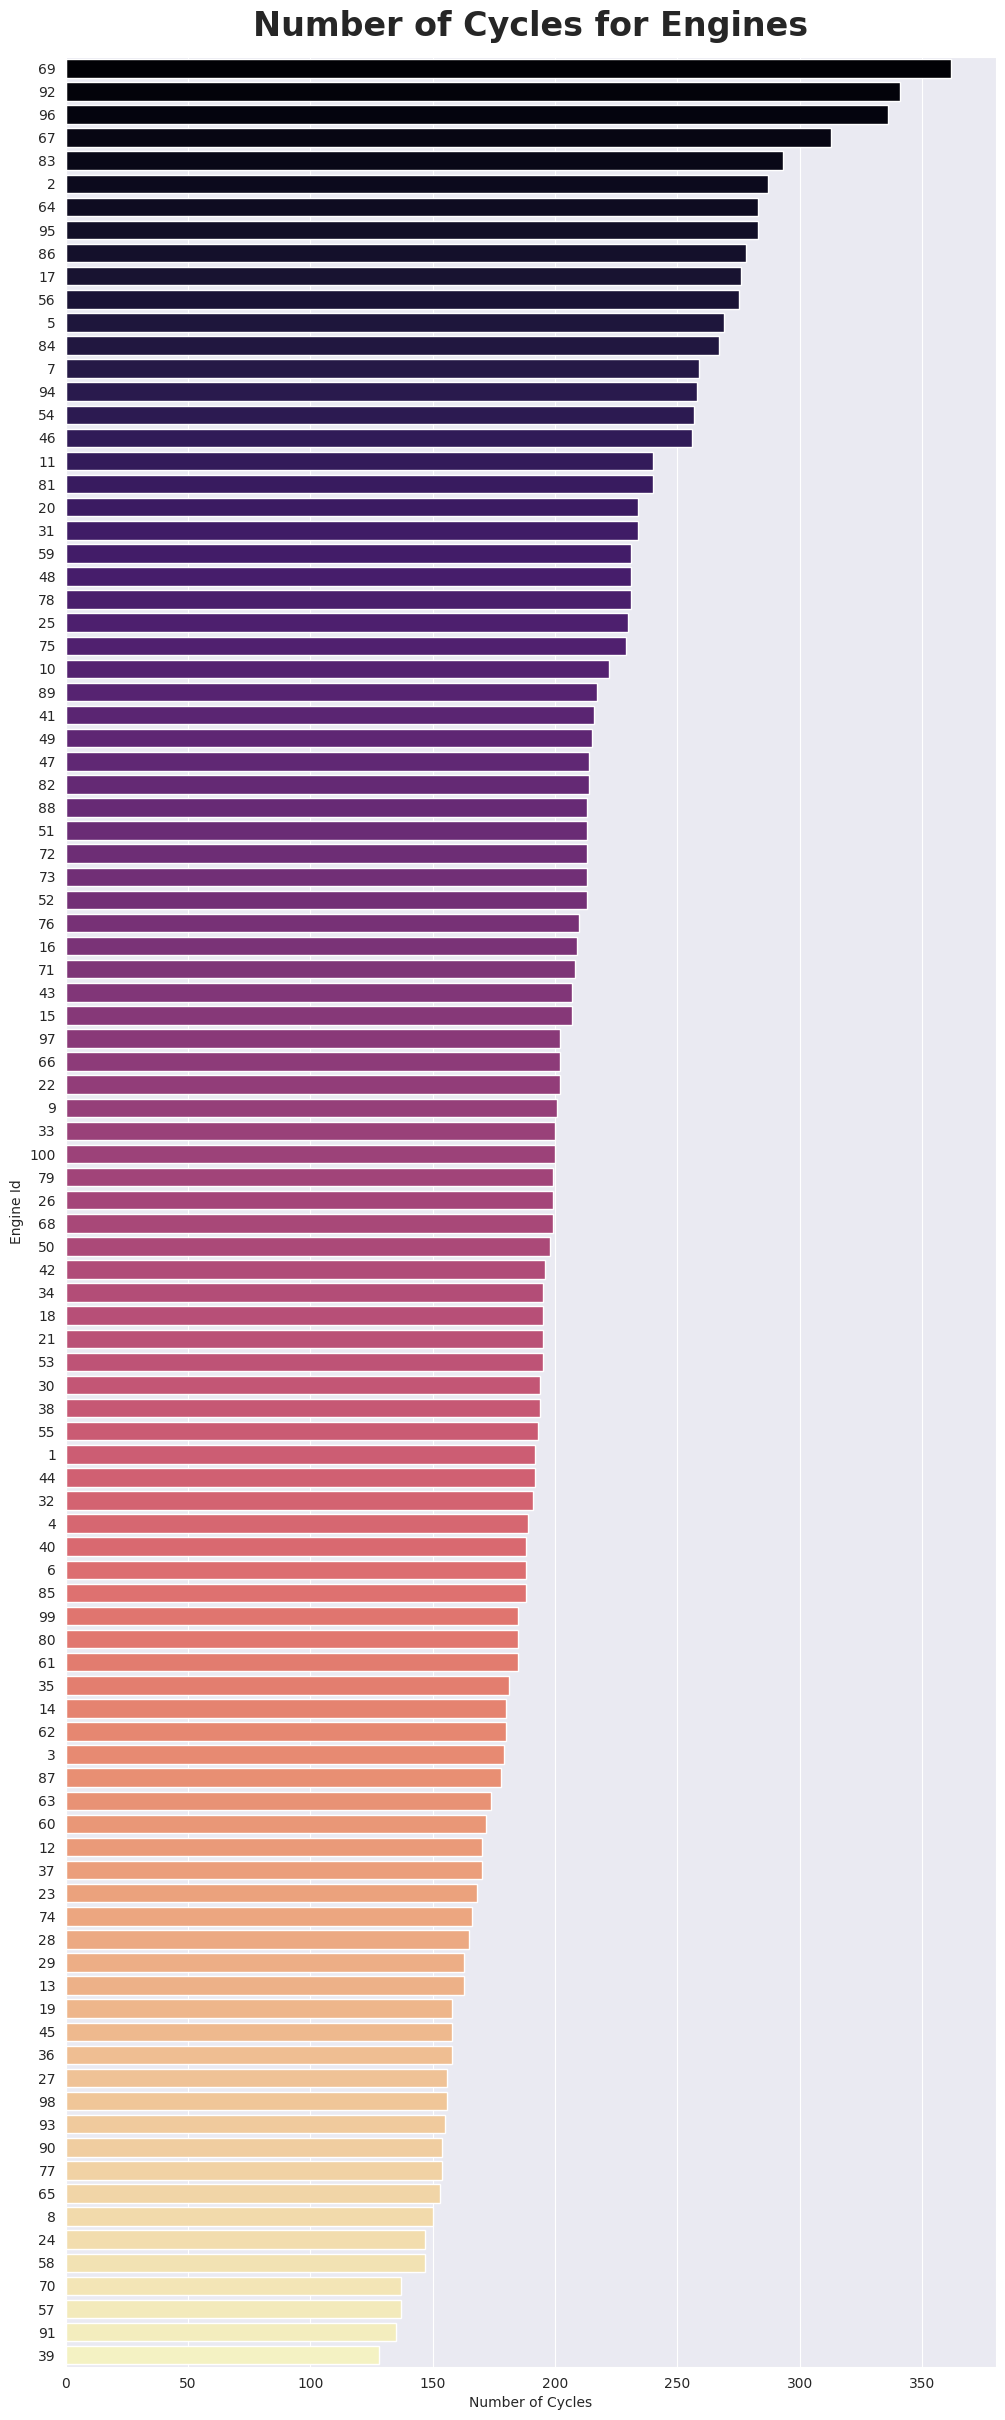

In [ ]:
cnt_train = train[["unit_ID", "cycles"]].groupby("unit_ID").max().sort_values(by="cycles", ascending=False)
cnt_ind = [str(i) for i in cnt_train.index.to_list()]
cnt_val = list(cnt_train.cycles.values)

sns.set_style("darkgrid")
plt.figure(figsize=(12, 30))
sns.barplot(x=list(cnt_val), y=list(cnt_ind), palette='magma')
plt.xlabel('Number of Cycles')
plt.ylabel('Engine Id')
plt.title('Number of Cycles for Engines', fontweight='bold', fontsize=24, pad=15)

plt.show()

 Defines and compiles an LSTM-based regression model for RUL
 prediction, using a single LSTM layer followed by dense layers
 to output a scalar degradation estimate.

 (OBS! COPY OF BASELINE LSTM)

In [ ]:
FEAT_DIM = 17

# LSTM model
def create_model_diagnostics(window_size=window_length,feat_dim=FEAT_DIM):
    model = tf.keras.Sequential([
        tf.keras.Input(shape=(window_size, feat_dim)),

        # #layers.LSTM(128),
        # layers.LSTM(128,return_sequences=True),
        # #layers.BatchNormalization(),  # stable distribution
        # layers.Dropout(0.2),

        layers.LSTM(64),
        # layers.BatchNormalization(),  # stable distribution
        layers.Dropout(0.2),

        layers.Dense(32, activation='relu'),
        layers.Dense(1)
    ])

    model.compile(optimizer= tf.keras.optimizers.Adam(learning_rate=0.001), loss='mse', metrics=['mae'])
    return model

In [ ]:
# def create_model():
#     model = Sequential([
#         layers.Input(shape=(window_length, 17)),

#         layers.LSTM(128, return_sequences=True),
#         layers.Dropout(0.2),

#         layers.LSTM(64, return_sequences=False),
#         layers.Dropout(0.2),

#         layers.Dense(64, activation="relu"),
#         layers.Dense(1)
#     ])

#     model.compile(
#         loss="mse",
#         optimizer=tf.keras.optimizers.Adam(learning_rate=0.001)
#     )

#     return model

 Builds and compiles a two-layer LSTM regression model for RUL
 prediction, using dropout regularization and a dense output layer
 trained with MSE loss and MAE metric.

In [ ]:
def create_model():
    model = Sequential([
        layers.Input(shape=(window_length, 17)),

        layers.LSTM(
            64,
            return_sequences=True,
            dropout=0.2,
            recurrent_dropout=0.2
        ),

        layers.LSTM(
            32,
            dropout=0.2,
            recurrent_dropout=0.2
        ),

        layers.Dense(32, activation="relu"),
        layers.Dropout(0.2),

        layers.Dense(1)
    ])

    # optimizer = tf.keras.optimizers.Adam(
    #     learning_rate=3e-4,
    #     clipnorm=1.0
    # )

    # model.compile(
    #     optimizer=optimizer,
    #     loss=tf.keras.losses.Huber(),
    #     metrics=["mae"]
    # )

    model.compile(
        optimizer= tf.keras.optimizers.Adam(learning_rate=0.001),
        loss='mse',
        metrics=['mae']
    )

    return model

In [ ]:
# # EarlyStopping
# early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True, verbose=0)

# # why factor 0.5， defult 0.1
# # combine the patience=5, use factor 0.5, make the model slowly reduce the learning rate
# # If use factor 0.1 may make model directly freeze when training, cant learn any more.

# # Reduce learing rate
# reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, min_lr=1e-5, verbose=0)


In [ ]:
# reduce_lr = ReduceLROnPlateau(
#     monitor="val_loss",
#     factor=0.5,
#     patience=3,
#     min_lr=1e-5,
#     verbose=0
# )

# early_stop = tf.keras.callbacks.EarlyStopping(
#     monitor="val_loss",
#     patience=10,
#     restore_best_weights=True,
#     verbose=1
# )

Function to reacreate callbacks for every instance needed.

In [ ]:
def get_callbacks():
    reduce_lr = ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=3,
        min_lr=1e-6,
        verbose=0
    )

    early_stopping = tf.keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=10,
        restore_best_weights=True,
        verbose=1
    )

    return [reduce_lr, early_stopping]

#Coreset Functions

 Allocates a sampling budget across RUL bins using a weighted
 combination of importance, gradient diversity, and bin size,
 while enforcing minimum/maximum constraints and redistributing
 to satisfy the total budget.

In [ ]:
def allocate_budget_per_bin(
    y,
    similarity_stats,
    bins,
    importance_dict,
    total_budget,
    alpha=1.0,
    beta=1.0,
    gamma=0.5,
    eps=1e-8,
    min_bin_frac=0.05,
    max_bin_frac=0.45
):

    total_samples = len(y)

    stats = []


    # Compute bin masks

    bin_masks = []

    for i in range(len(bins) - 1):
        low, high = bins[i], bins[i + 1]
        mask = (y >= low) & (y < high)
        bin_masks.append(mask)

    bin_masks = np.array(bin_masks, dtype=object)


    # Compute raw signals

    raw_importance = []
    raw_diversity = []
    raw_size = []

    for i in range(len(bin_masks)):

        mask = bin_masks[i]
        size = np.sum(mask)

        raw_size.append(size / total_samples)

        if size == 0:
            raw_importance.append(0.0)
            raw_diversity.append(0.0)
            continue

        avg_sim = similarity_stats.get(i, 0.0)
        avg_sim_value = avg_sim["similarity"] if isinstance(avg_sim, dict) else avg_sim

        imp = importance_dict.get(i, 0.0)
        div = 1.0 - avg_sim_value

        raw_importance.append(imp)
        raw_diversity.append(div)

    raw_importance = np.array(raw_importance)
    raw_diversity = np.array(raw_diversity)
    raw_size = np.array(raw_size)


    # normalize signals

    def normalize(x):
        x = np.asarray(x)
        return (x - x.min()) / (x.max() - x.min() + eps)

    importance = normalize(raw_importance)
    diversity = normalize(raw_diversity)
    size_factor = normalize(raw_size)


    # stable convex combination

    priority = (
        0.5 * importance +
        0.3 * diversity +
        0.2 * size_factor
    )

    priority = np.maximum(priority, eps)
    probs = priority / np.sum(priority)


    # enforce failure-region protection

    y_low_fraction = np.mean(y < 50)

    min_alloc = np.zeros_like(probs)
    max_alloc = np.zeros_like(probs)

    for i in range(len(probs)):

        # stronger protection for low-RUL bins
        if bins[i] < 50:
            min_alloc[i] = int(0.1 * total_budget)
            max_alloc[i] = int(0.6 * total_budget)
        else:
            min_alloc[i] = int(min_bin_frac * total_budget)
            max_alloc[i] = int(max_bin_frac * total_budget)


    # Initial allocation

    allocations = np.round(probs * total_budget).astype(int)


    # enforce bounds safely

    allocations = np.minimum(allocations, max_alloc)
    allocations = np.maximum(allocations, min_alloc)


    # redistribute to match budget

    diff = total_budget - np.sum(allocations)

    if diff != 0:

        order = np.argsort(priority)[::-1]

        i = 0
        while diff != 0:

            idx = order[i % len(order)]

            if diff > 0 and allocations[idx] < max_alloc[idx]:
                allocations[idx] += 1
                diff -= 1

            elif diff < 0 and allocations[idx] > min_alloc[idx]:
                allocations[idx] -= 1
                diff += 1

            i += 1


    # final output

    for i in range(len(bins) - 1):

        stats.append({
            "bin": i,
            "indices": np.where(bin_masks[i])[0],
            "priority": float(priority[i]),
            "allocated": int(allocations[i])
        })

    return stats

 Performs greedy submodular selection of k representative samples
 by iteratively choosing points that maximize marginal diversity
 based on cosine similarity coverage.

In [ ]:
def greedy_submodular_selection(features, k):
    N = features.shape[0]

    if k >= N:
        return np.arange(N)

    # normalize safely
    norms = np.linalg.norm(features, axis=1, keepdims=True)
    norms = np.clip(norms, 1e-8, None)
    features = features / norms

    sim_matrix = features @ features.T

    max_sim = np.zeros(N)
    selected = []
    selected_mask = np.zeros(N, dtype=bool)

    for _ in range(k):

        gains = np.maximum(sim_matrix - max_sim[:, None], 0).sum(axis=0)

        gains = np.where(selected_mask, -1e18, gains)

        j = np.argmax(gains)

        selected.append(j)
        selected_mask[j] = True

        max_sim = np.maximum(max_sim, sim_matrix[:, j])

    return np.array(selected)

 Builds a coreset by applying greedy submodular selection within
 each RUL bin allocation, ensuring diverse gradient-representative
 samples are selected according to the assigned budget.

In [ ]:
def build_coreset_with_submodular(X, y, allocation, gradient_features):
    selected_indices = []

    for s in allocation:
        idx = s["indices"]
        k = s["allocated"]

        if len(idx) <= k:
            selected_indices.extend(idx)
        else:
            feats = gradient_features[idx]

            selected_local = greedy_submodular_selection(feats, k)

            selected_indices.extend(idx[selected_local])

    return np.array(selected_indices)

 Extracts latent representations from the final layer of
 the model for each sample, intended as gradient-informed feature
 embeddings for downstream selection and analysis.

In [ ]:
def extract_gradient_latent_features_batch(model, X, y, batch_size=128):

    latent_layer = model.layers[-2].output

    feature_model = Model(
        inputs=model.inputs,
        outputs=[model.outputs, latent_layer]
    )

    dataset = tf.data.Dataset.from_tensor_slices((X, y)).batch(batch_size)

    features = []

    for x_batch, y_batch in dataset:
        with tf.GradientTape() as tape:
            outputs = feature_model(x_batch, training=False)

            preds = outputs[0]
            latent = outputs[1]

            preds = tf.reshape(preds, (-1,))
            y_batch = tf.cast(y_batch, tf.float32)

            loss = tf.square(preds - y_batch)

        grads = tape.gradient(loss, preds)

        latent_flat = tf.reshape(latent, [latent.shape[0], -1])

        #g = grads[:, None] * latent_flat  # caused errors
        g = latent_flat

        features.append(g.numpy())

    return np.vstack(features)

 Computes a custom asymmetric scoring function for RUL predictions,
 penalizing late and early predictions differently using exponential
 error terms and summing across all samples.

In [ ]:
def compute_s_score(rul_true, rul_pred):
    error = rul_pred - rul_true

    penalty = np.where(
        error < 0,
        np.exp(-error / 13) - 1,
        np.exp(error / 10) - 1
    )

    return np.sum(penalty)

#Chunks

 Builds overlapping temporal chunks per engine and assigns each
 chunk to a RUL bin based on its minimum RUL value to preserve
 degradation-stage consistency across sequences.

In [ ]:
def build_sequence_chunks(
    engine_ids,
    y,
    bins,
    chunk_size=10,
    stride=5
):

    if stride is None:
        stride = chunk_size

    chunks = []

    unique_engines = np.unique(engine_ids)

    for eng in unique_engines:

        eng_idx = np.where(engine_ids == eng)[0]
        eng_idx = np.sort(eng_idx)

        for start in range(
            0,
            len(eng_idx) - chunk_size + 1,
            stride
        ):

            chunk_idx = eng_idx[
                start:start + chunk_size
            ]


            chunk_rul = np.min(y[chunk_idx])


            # Safe bin assignment

            bin_id = None

            for i in range(len(bins) - 1):

                # Final bin includes right edge
                if i == len(bins) - 2:

                    if bins[i] <= chunk_rul <= bins[i + 1]:
                        bin_id = i
                        break

                else:

                    if bins[i] <= chunk_rul < bins[i + 1]:
                        bin_id = i
                        break

            if bin_id is None:
                continue

            chunks.append({
                "indices": chunk_idx,
                "engine_id": eng,
                "bin": bin_id,
                "min_rul": chunk_rul
            })

    return chunks

 Constructs a normalized feature vector for each temporal chunk
 by combining gradient direction and magnitude with mild
 time-weighting to emphasize later timesteps.

In [ ]:
def compute_chunk_features(
        chunks,
        gradient_directions,
        gradient_magnitudes
    ):

    chunk_features = []

    for chunk in chunks:

        idx = chunk["indices"]

        if len(idx) == 0:
            chunk_features.append(np.zeros_like(gradient_directions[0]))
            continue


        # use full chunk with weighted tail emphasis

        weights = np.linspace(0.5, 1.0, len(idx))  # mild tail bias, not hard cutoff

        dir_part = gradient_directions[idx]
        mag_part = gradient_magnitudes[idx]


        # magnitude-weighted representation

        weighted = dir_part * mag_part

        feat = np.average(weighted, axis=0, weights=weights)


        # proper normalization (standard L2)

        norm = np.linalg.norm(feat)

        if norm > 1e-8:
            feat = feat / norm

        chunk_features.append(feat)

    return np.stack(chunk_features)

 Groups chunk indices by their assigned RUL bin, producing a
 dictionary that maps each bin to the list of corresponding chunks.

In [ ]:
def group_chunks_by_bin(chunks):
    bins_dict = {}

    for i, chunk in enumerate(chunks):
        b = chunk["bin"]
        bins_dict.setdefault(b, []).append(i)

    return bins_dict

 Performs greedy submodular selection of representative chunks
 using cosine similarity coverage and incremental gain updates
 to maximize diversity within a fixed budget.

In [ ]:
def submodular_select_chunks(
    chunk_indices,
    features,
    budget
):

    if budget <= 0:
        return []

    if len(chunk_indices) <= budget:
        return list(chunk_indices)

    feats = features[chunk_indices]


    # cosine normalization

    norms = np.linalg.norm(feats, axis=1, keepdims=True)
    feats = feats / (norms + 1e-8)

    sim_matrix = feats @ feats.T

    n = len(chunk_indices)

    selected = []
    remaining = set(range(n))


    # initialization (medoid-like)

    mean_sim = sim_matrix.mean(axis=1)
    first = np.argmax(mean_sim)

    selected.append(first)
    remaining.remove(first)

    # Precompute current coverage vector
    current_coverage = sim_matrix[:, first].copy()


    # greedy incremental gain

    while len(selected) < budget and remaining:

        best_gain = -np.inf
        best_idx = None

        for r in remaining:

            # incremental update
            new_coverage = np.maximum(current_coverage, sim_matrix[:, r])
            gain = np.sum(new_coverage) - np.sum(current_coverage)

            if gain > best_gain:
                best_gain = gain
                best_idx = r

        selected.append(best_idx)
        remaining.remove(best_idx)

        current_coverage = np.maximum(
            current_coverage,
            sim_matrix[:, best_idx]
        )

    return [
        chunk_indices[i]
        for i in selected
    ]

 Builds a coreset from RUL chunks by allocating per-bin budgets,
 selecting representative chunks using engine-aware heuristics
 and greedy ranking, then enforcing a final compression target
 with safe downsampling or information-based backfilling.

In [ ]:
def build_coreset_from_chunks(
    X,
    y,
    chunks,
    chunk_features,
    allocation_per_bin,
    compression_ratio
):

    bins_dict = group_chunks_by_bin(chunks)

    selected_chunks = []

    print("\n=== CHUNK DEBUG ===")

    for b, chunk_ids in bins_dict.items():

        sample_budget = allocation_per_bin.get(b, 0)

        if sample_budget <= 0:
            continue

        chunk_sizes = {
            cid: len(chunks[cid]["indices"])
            for cid in chunk_ids
        }

        total_samples = sum(chunk_sizes.values())

        print(
            f"Bin {b}: "
            f"chunks={len(chunk_ids)}, "
            f"samples={total_samples}, "
            f"allocated={sample_budget}"
        )


        # CASE 1: full bin fits

        if total_samples <= sample_budget:
            selected_chunks.extend(chunk_ids)
            continue


        # ENGINE GROUPING

        engine_to_chunks = defaultdict(list)

        for cid in chunk_ids:
            eng = chunks[cid]["engine_id"]
            engine_to_chunks[eng].append(cid)

        selected_local = []
        used_budget = 0

        rng = np.random.default_rng(42)


        # STEP 1: ENGINE-AWARE SEEDING

        engine_order = list(engine_to_chunks.keys())
        rng.shuffle(engine_order)

        for eng in engine_order:

            candidates = engine_to_chunks[eng]

            # pick BEST chunk per engine
            best_chunk = max(
                candidates,
                key=lambda cid: np.mean(chunk_features[cid])
            )

            csize = len(chunks[best_chunk]["indices"])

            if used_budget + csize > sample_budget:
                continue

            selected_local.append(best_chunk)
            used_budget += csize


        # STEP 2: remaining pool

        remaining_chunks = [
            cid for cid in chunk_ids
            if cid not in selected_local
        ]


        # STEP 3: greedy fill (budget-safe)

        if len(remaining_chunks) > 0:

            ranked_chunks = sorted(
                remaining_chunks,
                key=lambda cid: np.mean(chunk_features[cid]),
                reverse=True
            )

            for cid in ranked_chunks:

                csize = len(chunks[cid]["indices"])

                if used_budget + csize > sample_budget:
                    continue

                selected_local.append(cid)
                used_budget += csize

                if used_budget >= sample_budget:
                    break

        selected_chunks.extend(selected_local)


    # FLATTEN

    selected_indices = []

    for cid in selected_chunks:
        selected_indices.extend(chunks[cid]["indices"])

    selected_indices = np.array(selected_indices, dtype=np.int32)


    # SAFE DEDUP

    selected_indices = np.unique(selected_indices)


    # HARD BUDGET ENFORCEMENT (UNBIASED)

    target_size = int(len(y) * compression_ratio)

    if len(selected_indices) > target_size:

        rng = np.random.default_rng(42)

        selected_indices = rng.choice(
            selected_indices,
            size=target_size,
            replace=False
        )


    # UNDERFILL

    if len(selected_indices) < target_size:

        deficit = target_size - len(selected_indices)

        remaining = np.setdiff1d(
            np.arange(len(y)),
            selected_indices
        )

        # prioritize high-information samples
        scores = np.abs(y[remaining] - np.median(y))

        extra = remaining[
            np.argsort(scores)[::-1][:deficit]
        ]

        selected_indices = np.concatenate([selected_indices, extra])

    return np.sort(selected_indices)

#Coreset construction

 Builds a compressed coreset dataset by allocating per-bin budgets,
 extracting gradient-based chunk features, and selecting representative
 samples via submodular chunk selection with strict size enforcement
 and under/overfill correction.

In [ ]:
def build_coreset_dataset_from_features(
    X,
    y,
    engine_ids,
    gradient_features,
    similarity_stats,
    bins,
    compression_ratio,
    importance_dict
):
    print(f"\n--- Building coreset ({compression_ratio*100:.0f}%) ---")

    target_size = int(compression_ratio * len(y))

    allocation = allocate_budget_per_bin(
        y,
        similarity_stats,
        bins,
        importance_dict,
        total_budget=target_size
    )

    allocation_dict = {s["bin"]: s["allocated"] for s in allocation}

    if DEBUG_MODE:
        print("\n=== BIN ALLOCATION ===")
        for s in allocation:
            print(
                f"Bin {s['bin']}: allocated={s['allocated']}"
            )


    # gradient decomposition (direction + magnitude)

    gradient_magnitudes = np.linalg.norm(
        gradient_features,
        axis=1,
        keepdims=True
    )

    gradient_directions = gradient_features / (gradient_magnitudes + 1e-8)

    assert not np.isnan(gradient_directions).any(), (
        "NaNs detected in gradient directions!"
    )

    assert not np.isnan(gradient_magnitudes).any(), (
        "NaNs detected in gradient magnitudes!"
    )

    # Stabilize magnitude distribution
    gradient_magnitudes = np.log1p(gradient_magnitudes)


    # Chunk construction

    chunks = build_sequence_chunks(engine_ids, y, bins)

    # pass BOTH direction + magnitude
    chunk_features = compute_chunk_features(
        chunks,
        gradient_directions,
        gradient_magnitudes
    )


    # Core selection

    selected_idx = build_coreset_from_chunks(
        X,
        y,
        chunks,
        chunk_features,
        allocation_dict,
        compression_ratio
    )


    # strict deduplication

    selected_idx = np.unique(selected_idx)


    # size enforcement (no temporal bias)

    if len(selected_idx) > target_size:

        print(
            f"\nWARNING: coreset exceeded target size "
            f"({len(selected_idx)} > {target_size})"
        )

        # Deterministic but unbiased downsampling
        rng = np.random.default_rng(42)
        rng.shuffle(selected_idx)

        selected_idx = selected_idx[:target_size]


    # underfill correction

    if len(selected_idx) < target_size:

        print(
            f"\nWARNING: underfilled coreset "
            f"({len(selected_idx)} < {target_size})"
        )

        deficit = target_size - len(selected_idx)

        all_idx = np.arange(len(y))
        remaining_idx = np.setdiff1d(all_idx, selected_idx)

        # Use magnitude as fallback importance signal
        scores = gradient_magnitudes[remaining_idx].flatten()

        extra_idx = remaining_idx[
            np.argsort(scores)[::-1][:deficit]
        ]

        selected_idx = np.concatenate([selected_idx, extra_idx])

    selected_idx = np.sort(selected_idx)


    # DEBUG: Engine coverage

    engine_ids_core = engine_ids[selected_idx]

    print("\n=== ENGINE COVERAGE DEBUG ===")
    print("Total engines:", len(np.unique(engine_ids)))
    print("Coreset engines:", len(np.unique(engine_ids_core)))

    engine_counts = np.bincount(engine_ids_core)

    print("Engine coverage stats:")
    print("min:", np.min(engine_counts))
    print("mean:", np.mean(engine_counts))
    print("max:", np.max(engine_counts))

    return X[selected_idx], y[selected_idx], selected_idx

 Creates a stratified random coreset by sampling within RUL
 quantile bins and enforcing an overall compression ratio
 with optional final size correction.

In [ ]:
def random_coreset(X, y, ratio, seed=42):

    rng = np.random.default_rng(seed)

    n = len(y)

    target_size = int(ratio * n)

    bins = np.percentile(
        y,
        [0, 25, 50, 75, 100]
    )

    idx_all = []

    for i in range(len(bins) - 1):

        if i == len(bins) - 2:

            bin_idx = np.where(
                (y >= bins[i]) &
                (y <= bins[i + 1])
            )[0]

        else:

            bin_idx = np.where(
                (y >= bins[i]) &
                (y < bins[i + 1])
            )[0]

        if len(bin_idx) == 0:
            continue

        k = max(
            1,
            int(len(bin_idx) * ratio)
        )

        chosen = rng.choice(
            bin_idx,
            size=min(k, len(bin_idx)),
            replace=False
        )

        idx_all.append(chosen)

    idx = np.concatenate(idx_all)

    idx = np.unique(idx)

    # Enforce exact size
    if len(idx) > target_size:

        idx = rng.choice(
            idx,
            size=target_size,
            replace=False
        )

    idx = np.sort(idx)

    return X[idx], y[idx]

 Trains a fresh LSTM model on provided data and evaluates it
 using engine-level last-window predictions, reporting RMSE,
 custom S-score, and training time.

In [ ]:
def train_and_evaluate_model(
    X_train,
    y_train,
    X_val,
    y_val,
    X_test,
    num_test_windows_list,
    true_rul,
    label="",
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    seed=42,
    verbose=0
):

    # Reproducibility

    np.random.seed(seed)
    random.seed(seed)
    tf.random.set_seed(seed)

    tf.keras.backend.clear_session()


    # Create + train model

    model = create_model()

    start_time = time.time()

    history = model.fit(
        X_train,
        y_train,
        validation_data=(X_val, y_val),
        epochs=EPOCHS,
        batch_size=BATCH_SIZE,
        #callbacks=[early_stop, reduce_lr],
        callbacks=get_callbacks(),
        verbose=1,
        shuffle=True
    )


    train_time = time.time() - start_time


    # Predict on all test windows

    rul_pred = model.predict(
        X_test,
        verbose=0
    ).reshape(-1)


    # Safety check

    expected = np.sum(num_test_windows_list)

    assert len(rul_pred) == expected, (
        f"Prediction mismatch! "
        f"Expected {expected}, "
        f"got {len(rul_pred)}"
    )


    # Split by engine

    preds_split = np.split(
        rul_pred,
        np.cumsum(num_test_windows_list)[:-1]
    )


    # CMAPSS convention: use final window prediction

    last_preds = np.array([
        p[-1] for p in preds_split
    ])

    assert len(last_preds) == len(true_rul)


    # Metrics

    rmse_last = np.sqrt(
        mean_squared_error(
            true_rul,
            last_preds
        )
    )

    s_score = compute_s_score(
        true_rul,
        last_preds
    )

    print(f"\n[{label}] RMSE (last): {rmse_last:.4f}")
    print(f"[{label}] S-score: {s_score:.2f}")
    print(f"[{label}] Train time: {train_time:.2f}s")

    return {
        "model": model,
        "history": history.history,
        "rmse_last": float(rmse_last),
        "s_score": float(s_score),
        "train_time": float(train_time),
        "preds_last": last_preds
    }

#Pipeline

 Runs full experiments comparing full dataset training,
 importance-aware coreset selection, and random baselines
 across multiple compression ratios, including diagnostics,
 evaluation, and visualization of RUL prediction performance.

In [ ]:
def run_experiments_with_baselines(
    X,
    y,
    engine_ids,
    X_val,
    y_val,
    X_test,
    num_test_windows_list,
    true_rul,
    similarity_stats,
    bins,
    importance_dict,
    compression_ratios=[0.7, 0.5, 0.3],
    seed=42,
    debug_mode=True
):


    # Reproducibility

    np.random.seed(seed)
    random.seed(seed)
    tf.random.set_seed(seed)

    results = {}

    all_coresets = {}


    # Sanity check

    if debug_mode:

        print("\n=== DATA SANITY CHECK ===")

        print("X:", X.shape)
        print("y:", y.shape)
        print("engine_ids:", engine_ids.shape)

        assert len(X) == len(y) == len(engine_ids)

        print("Unique engines:", len(np.unique(engine_ids)))


        # Full dataset RUL distribution

        print("\n=== FULL DATASET RUL DISTRIBUTION ===")

        for i in range(len(bins) - 1):

            if i == len(bins) - 2:

                mask = (
                    (y >= bins[i]) &
                    (y <= bins[i + 1])
                )

            else:

                mask = (
                    (y >= bins[i]) &
                    (y < bins[i + 1])
                )

            print(
                f"Bin {i}: "
                f"range=[{bins[i]}, {bins[i+1]}], "
                f"count={np.sum(mask)}"
            )


    # Train feature model for coreset selection

    print("\nTraining feature model for gradient extraction...")

    tf.keras.backend.clear_session()

    np.random.seed(seed)
    random.seed(seed)
    tf.random.set_seed(seed)

    feature_model = create_model()

    feature_model.fit(
        X,
        y,
        validation_data=(X_val, y_val),
        epochs=EPOCHS,
        batch_size=BATCH_SIZE,
        callbacks=get_callbacks(),
        verbose=1,
        shuffle=True
    )


    # Extract gradient features

    print("Extracting gradient features...")

    gradient_features = extract_gradient_latent_features_batch(
        feature_model,
        X,
        y
    )

    if debug_mode:

        print("\n=== FEATURE STATS ===")

        print("Mean:", np.mean(gradient_features))
        print("Std:", np.std(gradient_features))
        print("Min:", np.min(gradient_features))
        print("Max:", np.max(gradient_features))


    # Normalize safely

    norms = np.linalg.norm(
        gradient_features,
        axis=1,
        keepdims=True
    )

    gradient_features = (
        gradient_features /
        (norms + 1e-8)
    )

    assert not np.isnan(gradient_features).any(), (
        "NaNs detected in gradient features!"
    )


    # FULL baseline

    print("\n===== FULL DATASET BASELINE =====")

    full_res = train_and_evaluate_model(
        X_train=X,
        y_train=y,
        X_val=X_val,
        y_val=y_val,
        X_test=X_test,
        num_test_windows_list=num_test_windows_list,
        true_rul=true_rul,
        label="FULL",
        epochs=EPOCHS,
        batch_size=BATCH_SIZE,
        seed=seed
    )

    full_preds = full_res["preds_last"]

    results["FULL"] = {
        "ratio": 1.0,
        **full_res
    }


    # Compression loop

    for ratio in compression_ratios:

        print(f"\n===== Compression Ratio: {ratio:.2f} =====")


        # Build coreset

        X_core, y_core, selected_idx = build_coreset_dataset_from_features(
            X=X,
            y=y,
            engine_ids=engine_ids,
            gradient_features=gradient_features,
            similarity_stats=similarity_stats,
            bins=bins,
            compression_ratio=ratio,
            importance_dict=importance_dict
        )


        # Basic coreset stats

        print("\n--- Coreset Stats ---")

        print("Coreset size:", len(X_core))
        print("RUL mean:", np.mean(y_core))
        print("RUL std:", np.std(y_core))
        print("RUL min:", np.min(y_core))
        print("RUL max:", np.max(y_core))

        target_size = int(len(X) * ratio)

        print(
            f"Target size: {target_size}, "
            f"Actual: {len(X_core)}"
        )


        # DIAGNOSTICS

        if debug_mode:

            print("\n=== GLOBAL RETENTION ===")

            print(
                "Low-RUL retention (<20):",
                np.mean(y_core < 20)
            )

            print(
                "Original low-RUL fraction:",
                np.mean(y < 20)
            )

            print(
                "High-RUL retention (>100):",
                np.mean(y_core > 100)
            )

            print(
                "Original high-RUL fraction:",
                np.mean(y > 100)
            )


            # Per-bin retention diagnostics

            print("\n=== BIN RETENTION DIAGNOSTICS ===")

            for i in range(len(bins) - 1):

                if i == len(bins) - 2:

                    full_mask = (
                        (y >= bins[i]) &
                        (y <= bins[i + 1])
                    )

                    core_mask = (
                        (y_core >= bins[i]) &
                        (y_core <= bins[i + 1])
                    )

                else:

                    full_mask = (
                        (y >= bins[i]) &
                        (y < bins[i + 1])
                    )

                    core_mask = (
                        (y_core >= bins[i]) &
                        (y_core < bins[i + 1])
                    )

                full_count = np.sum(full_mask)
                core_count = np.sum(core_mask)

                retention = (
                    core_count / full_count
                    if full_count > 0 else 0.0
                )

                print(
                    f"Bin {i}: "
                    f"range=[{bins[i]}, {bins[i+1]}], "
                    f"full={full_count}, "
                    f"core={core_count}, "
                    f"retention={retention:.3f}"
                )


            # Distribution visualization

            plt.figure(figsize=(10, 5))

            plt.hist(
                y,
                bins=50,
                alpha=0.5,
                label="FULL"
            )

            plt.hist(
                y_core,
                bins=50,
                alpha=0.5,
                label=f"CORESET {ratio}"
            )

            plt.axvline(
                np.mean(y),
                color="blue",
                linestyle="--",
                label="Full mean"
            )

            plt.axvline(
                np.mean(y_core),
                color="orange",
                linestyle="--",
                label="Coreset mean"
            )

            plt.legend()

            plt.title(
                f"RUL Distribution Comparison ({ratio:.2f})"
            )

            plt.xlabel("RUL")
            plt.ylabel("Count")

            plt.show()


            # Quantile diagnostics

            print("\n=== QUANTILE DIAGNOSTICS ===")

            quantiles = [0, 10, 25, 50, 75, 90, 100]

            full_q = np.percentile(y, quantiles)
            core_q = np.percentile(y_core, quantiles)

            print("Quantile | Full | Coreset")

            for q, fq, cq in zip(
                quantiles,
                full_q,
                core_q
            ):

                print(
                    f"{q:>3}%     | "
                    f"{fq:>6.2f} | "
                    f"{cq:>6.2f}"
                )


            # Engine coverage diagnostics

            print("\n=== ENGINE COVERAGE ===")

            print(
                "Original engines:",
                len(np.unique(engine_ids))
            )

            core_engine_ids = engine_ids[selected_idx]

            print(
                "Coreset engines:",
                len(np.unique(core_engine_ids))
            )


            # Additional inspections

            inspect_coreset(
                X_core,
                y_core,
                bins
            )

            compare_distribution(
                y,
                y_core,
                bins
            )


        # Train/evaluate coreset

        res_core = train_and_evaluate_model(
            X_train=X_core,
            y_train=y_core,
            X_val=X_val,
            y_val=y_val,
            X_test=X_test,
            num_test_windows_list=num_test_windows_list,
            true_rul=true_rul,
            label=f"CORESET {int(ratio * 100)}%",
            epochs=EPOCHS,
            verbose=1,
            batch_size=BATCH_SIZE,
            seed=seed
        )

        core_preds = res_core["preds_last"]

        results[f"CORESET_{ratio}"] = {
            "ratio": ratio,
            **res_core
        }


        # Random baseline

        X_rand, y_rand = random_coreset(
            X,
            y,
            ratio
        )

        print("\n--- Random Baseline Stats ---")

        print("Size:", len(X_rand))
        print("RUL mean:", np.mean(y_rand))
        print("RUL std:", np.std(y_rand))

        if debug_mode:

            print(
                "Low-RUL fraction:",
                np.mean(y_rand < 20)
            )

            print(
                "High-RUL fraction:",
                np.mean(y_rand > 100)
            )

        res_rand = train_and_evaluate_model(
            X_train=X_rand,
            y_train=y_rand,
            X_val=X_val,
            y_val=y_val,
            X_test=X_test,
            num_test_windows_list=num_test_windows_list,
            true_rul=true_rul,
            label=f"RANDOM {int(ratio * 100)}%",
            epochs=EPOCHS,
            verbose=1,
            batch_size=BATCH_SIZE,
            seed=seed
        )

        rand_preds = res_rand["preds_last"]

        results[f"RANDOM_{ratio}"] = {
            "ratio": ratio,
            **res_rand
        }


        # Visualization

        plot_multiple_models(
            true_rul,
            {
                "FULL": full_preds,
                f"CORESET {int(ratio * 100)}%": core_preds,
                f"RANDOM {int(ratio * 100)}%": rand_preds
            }
        )

        plot_error(
            true_rul,
            core_preds,
            f"CORESET Error {ratio}"
        )


        all_coresets[ratio] = {
        "X_core": X_core,
        "y_core": y_core,
        "X_rand": X_rand,
        "y_rand": y_rand,
        "X_val": X_val,
        "y_val": y_val,
        "num_test_windows_list": num_test_windows_list
        }

    return results, all_coresets

#Debug Functions

 Computes and prints the number of unique engines represented
 in the selected coreset indices to assess engine-level coverage.

In [ ]:
def check_engine_coverage(selected_idx, engine_ids):
    unique_engines = np.unique(engine_ids[selected_idx])
    print("Selected engines:", len(unique_engines))

 Prints the number of coreset samples falling into each RUL bin
 to verify that the reduced dataset preserves distribution across
 degradation ranges.

In [ ]:
def inspect_coreset(X_core, y_core, bins):
    for i in range(len(bins)-1):
        low, high = bins[i], bins[i+1]
        count = np.sum((y_core >= low) & (y_core < high))
        print(f"Bin {i}: {count} samples")

 Compares the normalized bin-wise distribution of RUL values
 between the full dataset and the coreset to assess how well
 the sampling preserves the original distribution structure.

In [ ]:
def compare_distribution(y_full, y_core, bins):
    print("\nFULL:")
    for i in range(len(bins)-1):
        print(np.mean((y_full >= bins[i]) & (y_full < bins[i+1])))

    print("\nCORESET:")
    for i in range(len(bins)-1):
        print(np.mean((y_core >= bins[i]) & (y_core < bins[i+1])))

#Plotting

 Plots training efficiency by comparing RMSE against training time
 for coreset, random, and full dataset models to visualize trade-offs.

In [ ]:
def plot_efficiency(results):
    time_core, rmse_core = [], []
    time_rand, rmse_rand = [], []

    for k, v in results.items():
        if "CORESET" in k:
            time_core.append(v["train_time"])
            rmse_core.append(v["rmse_last"])

        elif "RANDOM" in k:
            time_rand.append(v["train_time"])
            rmse_rand.append(v["rmse_last"])

        elif "FULL" in k:
            full_time = v["train_time"]
            full_rmse = v["rmse_last"]

    plt.figure()
    plt.scatter(time_core, rmse_core, label="Coreset")
    plt.scatter(time_rand, rmse_rand, label="Random")

    plt.scatter([full_time], [full_rmse], label="Full Data", marker='*', s=200)

    plt.xlabel("Training Time (s)")
    plt.ylabel("RMSE")
    plt.title("Efficiency: RMSE vs Training Time")
    plt.legend()
    plt.grid()
    plt.show()

 Visualizes model performance (RMSE and S-score) as a function
 of dataset compression ratio, comparing coreset, random sampling,
 and full dataset baselines.

In [ ]:
def plot_performance_vs_compression(results):
    ratios = []
    rmse_core = []
    rmse_rand = []
    s_core = []
    s_rand = []

    for k, v in results.items():
        ratio = v["ratio"]

        if "CORESET" in k:
            ratios.append(ratio)
            rmse_core.append(v["rmse_last"])
            s_core.append(v["s_score"])

        elif "RANDOM" in k:
            rmse_rand.append(v["rmse_last"])
            s_rand.append(v["s_score"])

        elif "FULL" in k:
            full_rmse = v["rmse_last"]
            full_s = v["s_score"]

    ratios = sorted(list(set(ratios)))

    # Sort arrays consistently
    rmse_core = [x for _, x in sorted(zip(ratios, rmse_core))]
    rmse_rand = [x for _, x in sorted(zip(ratios, rmse_rand))]
    s_core = [x for _, x in sorted(zip(ratios, s_core))]
    s_rand = [x for _, x in sorted(zip(ratios, s_rand))]


    # RMSE plot

    plt.figure()
    plt.plot(ratios, rmse_core, marker='o', label="Coreset")
    plt.plot(ratios, rmse_rand, marker='x', linestyle='--', label="Random")

    plt.axhline(full_rmse, linestyle=':', label="Full Data")

    plt.xlabel("Dataset Size (ratio)")
    plt.ylabel("RMSE (last window)")
    plt.title("RMSE vs Compression")
    plt.legend()
    plt.grid()
    plt.show()


    # S-score plot

    plt.figure()
    plt.plot(ratios, s_core, marker='o', label="Coreset")
    plt.plot(ratios, s_rand, marker='x', linestyle='--', label="Random")

    plt.axhline(full_s, linestyle=':', label="Full Data")

    plt.xlabel("Dataset Size (ratio)")
    plt.ylabel("S-score")
    plt.title("S-score vs Compression")
    plt.legend()
    plt.grid()
    plt.show()

 Plots true vs predicted RUL values across engines to visually
 assess prediction accuracy and trend alignment.

In [ ]:
def plot_rul_predictions(true_rul, pred_rul, title="RUL Prediction"):

    plt.figure(figsize=(10, 5))
    plt.plot(true_rul, label="True RUL", linewidth=2)
    plt.plot(pred_rul, label="Pred RUL", linestyle="--", alpha=0.7)

    plt.title(title)
    plt.xlabel("Engine Index")
    plt.ylabel("RUL")
    plt.legend()
    plt.grid(True)

    plt.show()

 Plots true RUL alongside multiple model predictions for direct
 visual comparison of prediction quality across different methods.

In [ ]:
def plot_multiple_models(true_rul, predictions_dict):

    plt.figure(figsize=(12, 6))
    plt.plot(true_rul, label="True RUL", linewidth=3)

    for label, preds in predictions_dict.items():
        plt.plot(preds, label=label, linestyle="--", alpha=0.7)

    plt.legend()
    plt.title("Model Comparison")
    plt.xlabel("Engine Index")
    plt.ylabel("RUL")
    plt.grid(True)

    plt.show()

 Plots training time against dataset compression ratio,
 comparing coreset and random sampling methods against the
 full dataset baseline to illustrate computational savings.

In [ ]:
def plot_time_vs_compression(results):
    ratios = []
    time_core = []
    time_rand = []

    for k, v in results.items():
        ratio = v["ratio"]

        if "CORESET" in k:
            ratios.append(ratio)
            time_core.append(v["train_time"])

        elif "RANDOM" in k:
            time_rand.append(v["train_time"])

        elif "FULL" in k:
            full_time = v["train_time"]

    ratios = sorted(list(set(ratios)))

    # sort consistently
    time_core = [x for _, x in sorted(zip(ratios, time_core))]
    time_rand = [x for _, x in sorted(zip(ratios, time_rand))]


    # Plot

    plt.figure()
    plt.plot(ratios, time_core, marker='o', label="Coreset")
    plt.plot(ratios, time_rand, marker='x', linestyle='--', label="Random")

    plt.axhline(full_time, linestyle=':', label="Full Data")

    plt.xlabel("Dataset Size (ratio)")
    plt.ylabel("Training Time (seconds)")
    plt.title("Training Time vs Compression")
    plt.legend()
    plt.grid()
    plt.show()

 Plots prediction error (predicted minus true RUL) across engines
 to visualize bias, variance, and systematic over/under-estimation.

In [ ]:
def plot_error(true_rul, pred_rul, title):

    error = pred_rul - true_rul

    plt.figure(figsize=(10, 4))
    plt.plot(error)
    plt.axhline(0, linestyle="--")

    plt.title(title)
    plt.xlabel("Engine Index")
    plt.ylabel("Error")

    plt.grid(True)
    plt.show()

In [ ]:
# print("TRAIN TARGET RANGE:",
#       processed_train_targets.min(),
#       processed_train_targets.max())

In [ ]:
# print("Processed train data shape: ", processed_train_data.shape)
# print("Processed validation data shape: ", processed_val_data.shape)
# print("Processed train targets shape: ", processed_train_targets.shape)
# print("Processed validation targets shape: ", processed_val_targets.shape)
# print("Processed test data shape: ", processed_test_data.shape)
# print("True RUL shape: ", true_rul.shape)

#Run models

Run all the functions

In [ ]:
true_rul = rul[0].values


processed_train_data = process_dataset(
    train_df,
    window_length=window_length,
    shift=shift,
    is_train=True,
    early_rul=early_rul
)

processed_val_data = process_dataset(
    val_df,
    window_length=window_length,
    shift=shift,
    is_train=True,
    early_rul=early_rul
)

processed_test, num_test_windows_list = process_dataset(
    test_scaled,
    window_length=window_length,
    shift=shift,
    is_train=False,
    num_test_windows=num_test_windows
)

In [ ]:
diagnostics_results = run_rul_diagnostics(
    X_train=processed_train_data["X"],
    y_train=processed_train_data["y_clipped"],
    y_raw_train=processed_train_data["y_raw"],
    X_val=processed_val_data["X"],
    y_val=processed_val_data["y_clipped"],
    y_val_raw=processed_val_data["y_raw"],
    X_test=processed_test,
    num_windows=num_test_windows_list,
    true_rul=true_rul,
    run_gradients=RUN_GRADIENT_NORM,
    epochs=EPOCHS
)

Epoch 15: early stopping
Restoring model weights from the end of the best epoch: 5.

=== Per-Bin RMSE Evaluation ===
Bin 0 [0, 30): RMSE = 3.9353 | Samples = 25
Bin 1 [30, 60): RMSE = 7.8709 | Samples = 14
Bin 2 [60, 90): RMSE = 24.6198 | Samples = 13
Bin 3 [90, 125): RMSE = 12.5827 | Samples = 37
Bin 4 [125, inf): RMSE = 22.6758 | Samples = 11

=== Gradient Diversity Analysis (custom) ===

Bin 0
Range: [0.00, 30.00)
Samples: 2400
Avg cosine similarity: 0.0630

Bin 1
Range: [30.00, 60.00)
Samples: 2400
Avg cosine similarity: 0.0147

Bin 2
Range: [60.00, 90.00)
Samples: 2400
Avg cosine similarity: 0.0464

Bin 3
Range: [90.00, 125.00)
Samples: 2721
Avg cosine similarity: 0.0233

Bin 4
Range: [125.00, inf)
Samples: 4320
Avg cosine similarity: 0.5491

=== ALIGNMENT CHECK ===
X_thin shape: (14241, 30, 17)
y_thin shape: (14241,)
G shape: (14241, 23105)
bins total samples: 14241

=== RUL DISTRIBUTION CHECK ===
y min: 0.0000
y max: 332.0000
unique values: 333
Histogram: [2720 2640 2639 2475 19

In [ ]:
similarity_stats = diagnostics_results["similarity_stats"]
importance_dict = diagnostics_results["importance"]


=== DATA SANITY CHECK ===
X: (14241, 30, 17)
y: (14241,)
engine_ids: (14241,)
Unique engines: 80

=== FULL DATASET RUL DISTRIBUTION ===
Bin 0: range=[0, 30], count=2400
Bin 1: range=[30, 60], count=2400
Bin 2: range=[60, 90], count=2400
Bin 3: range=[90, 125], count=2721
Bin 4: range=[125, inf], count=4320

Training feature model for gradient extraction...
Epoch 1/100
223/223 ━━━━━━━━━━━━━━━━━━━━ 29s 91ms/step - loss: 5540.1572 - mae: 63.0314 - val_loss: 2440.2720 - val_mae: 40.4676 - learning_rate: 0.0010
Epoch 2/100
223/223 ━━━━━━━━━━━━━━━━━━━━ 20s 90ms/step - loss: 1221.2195 - mae: 27.5068 - val_loss: 329.6888 - val_mae: 14.9886 - learning_rate: 0.0010
Epoch 3/100
223/223 ━━━━━━━━━━━━━━━━━━━━ 18s 81ms/step - loss: 497.3582 - mae: 17.0646 - val_loss: 188.5210 - val_mae: 10.6746 - learning_rate: 0.0010
Epoch 4/100
223/223 ━━━━━━━━━━━━━━━━━━━━ 19s 85ms/step - loss: 420.8454 - mae: 15.5463 - val_loss: 183.7677 - val_mae: 9.8230 - learning_rate: 0.0010
Epoch 5/100
223/223 ━━━━━━━━━━━━━━

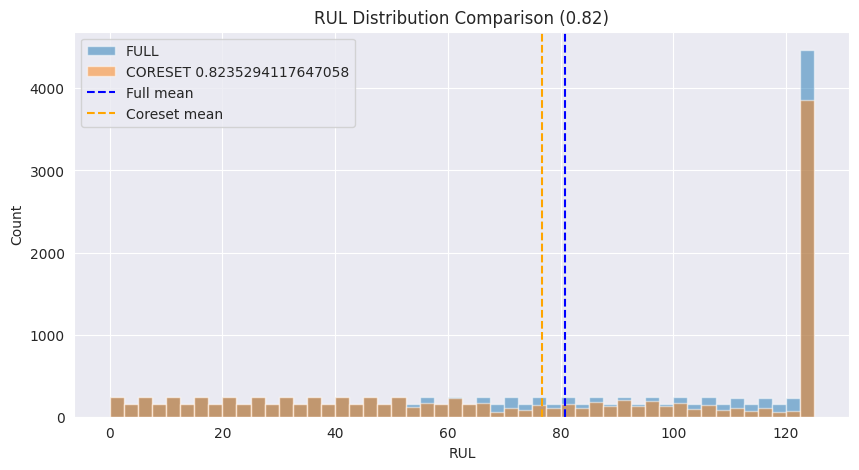


=== QUANTILE DIAGNOSTICS ===
Quantile | Full | Coreset
  0%     |   0.00 |   0.00
 10%     |  17.00 |  14.00
 25%     |  44.00 |  36.00
 50%     |  89.00 |  82.00
 75%     | 125.00 | 125.00
 90%     | 125.00 | 125.00
100%     | 125.00 | 125.00

=== ENGINE COVERAGE ===
Original engines: 80
Coreset engines: 80
Bin 0: 2400 samples
Bin 1: 2281 samples
Bin 2: 1622 samples
Bin 3: 1611 samples
Bin 4: 3813 samples

FULL:
0.16852749104697703
0.16852749104697703
0.16852749104697703
0.19106804297451022
0.3033494838845587

CORESET:
0.20465592223074955
0.19450839942014156
0.1383132941076149
0.13737528779739064
0.32514709644410333
Epoch 1/100
184/184 ━━━━━━━━━━━━━━━━━━━━ 26s 93ms/step - loss: 5730.5596 - mae: 63.2380 - val_loss: 3166.5137 - val_mae: 46.1657 - learning_rate: 0.0010
Epoch 2/100
184/184 ━━━━━━━━━━━━━━━━━━━━ 20s 90ms/step - loss: 1675.4297 - mae: 32.2866 - val_loss: 590.5471 - val_mae: 19.8182 - learning_rate: 0.0010
Epoch 3/100
184/184 ━━━━━━━━━━━━━━━━━━━━ 16s 86ms/step - loss: 607.29

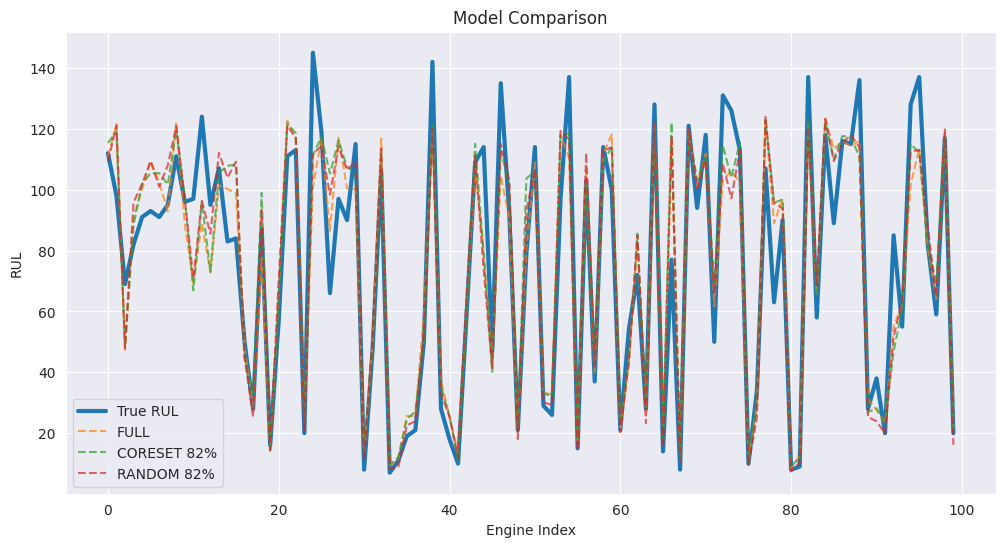

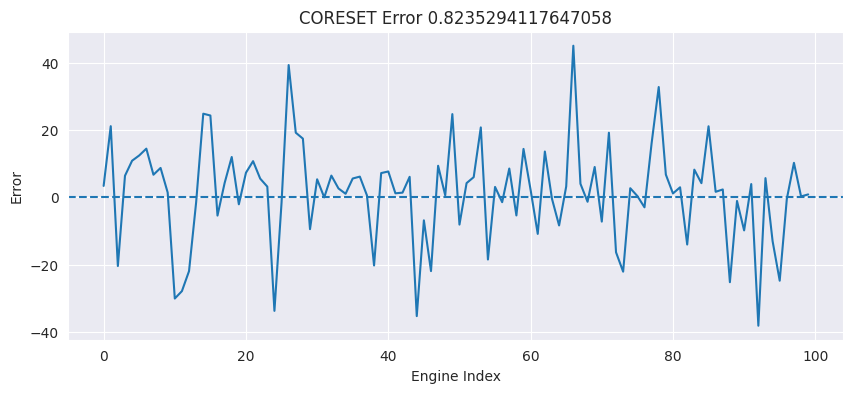


===== Compression Ratio: 0.65 =====

--- Building coreset (65%) ---

=== BIN ALLOCATION ===
Bin 0: allocated=1906
Bin 1: allocated=1139
Bin 2: allocated=1763
Bin 3: allocated=1747
Bin 4: allocated=2659

=== CHUNK DEBUG ===
Bin 4: chunks=767, samples=7670, allocated=2659
Bin 3: chunks=528, samples=5280, allocated=1747
Bin 2: chunks=480, samples=4800, allocated=1763
Bin 1: chunks=480, samples=4800, allocated=1139
Bin 0: chunks=480, samples=4800, allocated=1906

=== ENGINE COVERAGE DEBUG ===
Total engines: 80
Coreset engines: 80
Engine coverage stats:
min: 0
mean: 91.22772277227723
max: 227

--- Coreset Stats ---
Coreset size: 9214
RUL mean: 65.80844367267203
RUL std: 42.164541850209375
RUL min: 0
RUL max: 125
Target size: 9214, Actual: 9214

=== GLOBAL RETENTION ===
Low-RUL retention (<20): 0.17364879531148253
Original low-RUL fraction: 0.11235166069798469
High-RUL retention (>100): 0.2762101150423269
Original high-RUL fraction: 0.43276455305104977

=== BIN RETENTION DIAGNOSTICS ===
Bin

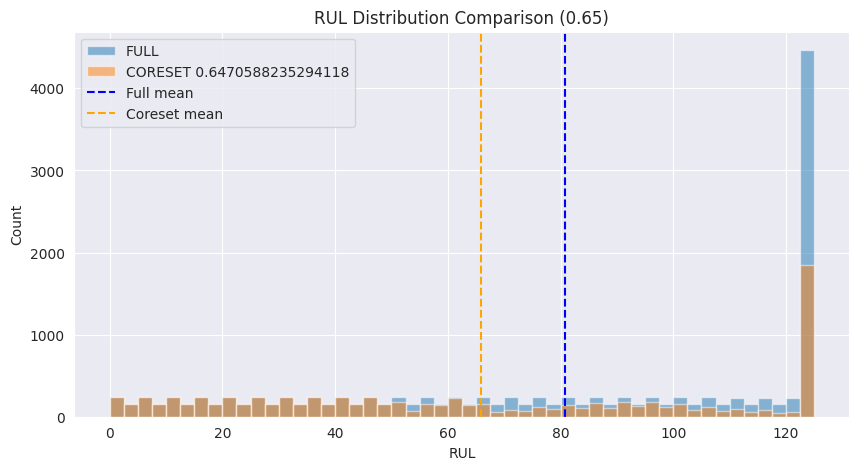


=== QUANTILE DIAGNOSTICS ===
Quantile | Full | Coreset
  0%     |   0.00 |   0.00
 10%     |  17.00 |  11.00
 25%     |  44.00 |  28.00
 50%     |  89.00 |  60.00
 75%     | 125.00 | 106.00
 90%     | 125.00 | 125.00
100%     | 125.00 | 125.00

=== ENGINE COVERAGE ===
Original engines: 80
Coreset engines: 80
Bin 0: 2400 samples
Bin 1: 2142 samples
Bin 2: 1466 samples
Bin 3: 1395 samples
Bin 4: 1811 samples

FULL:
0.16852749104697703
0.16852749104697703
0.16852749104697703
0.19106804297451022
0.3033494838845587

CORESET:
0.26047319296722377
0.23247232472324722
0.15910570870414587
0.15140004341219881
0.19654873019318428
Epoch 1/100
144/144 ━━━━━━━━━━━━━━━━━━━━ 23s 101ms/step - loss: 5024.7202 - mae: 57.7620 - val_loss: 5068.8066 - val_mae: 60.6306 - learning_rate: 0.0010
Epoch 2/100
144/144 ━━━━━━━━━━━━━━━━━━━━ 14s 95ms/step - loss: 2314.5627 - mae: 36.9799 - val_loss: 1519.9570 - val_mae: 31.4721 - learning_rate: 0.0010
Epoch 3/100
144/144 ━━━━━━━━━━━━━━━━━━━━ 13s 93ms/step - loss: 818

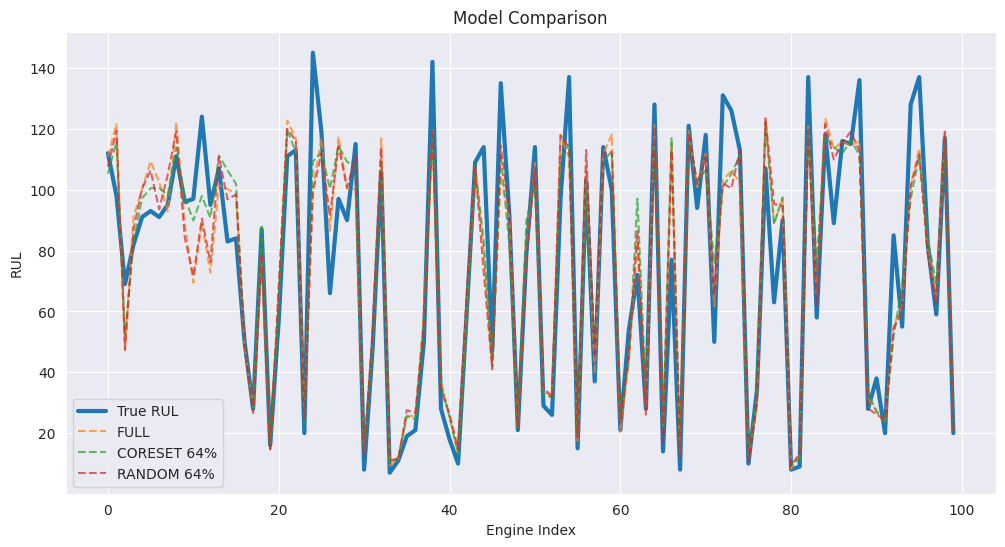

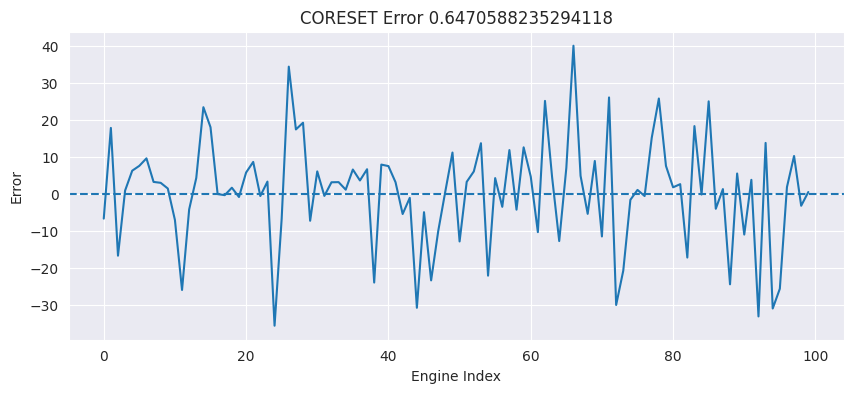


===== Compression Ratio: 0.47 =====

--- Building coreset (47%) ---

=== BIN ALLOCATION ===
Bin 0: allocated=1386
Bin 1: allocated=829
Bin 2: allocated=1282
Bin 3: allocated=1271
Bin 4: allocated=1933

=== CHUNK DEBUG ===
Bin 4: chunks=767, samples=7670, allocated=1933
Bin 3: chunks=528, samples=5280, allocated=1271
Bin 2: chunks=480, samples=4800, allocated=1282
Bin 1: chunks=480, samples=4800, allocated=829
Bin 0: chunks=480, samples=4800, allocated=1386

=== ENGINE COVERAGE DEBUG ===
Total engines: 80
Coreset engines: 80
Engine coverage stats:
min: 0
mean: 66.34653465346534
max: 184

--- Coreset Stats ---
Coreset size: 6701
RUL mean: 67.60438740486495
RUL std: 44.33714531866313
RUL min: 0
RUL max: 125
Target size: 6701, Actual: 6701

=== GLOBAL RETENTION ===
Low-RUL retention (<20): 0.22787643635278318
Original low-RUL fraction: 0.11235166069798469
High-RUL retention (>100): 0.30114908222653336
Original high-RUL fraction: 0.43276455305104977

=== BIN RETENTION DIAGNOSTICS ===
Bin 0

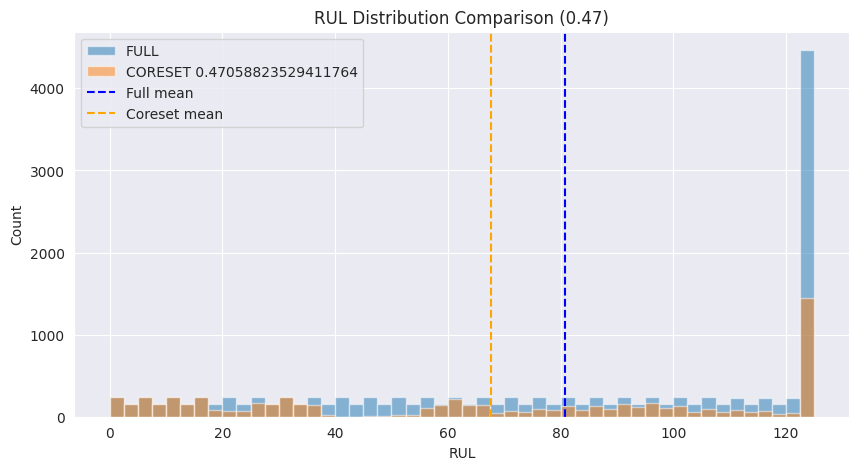


=== QUANTILE DIAGNOSTICS ===
Quantile | Full | Coreset
  0%     |   0.00 |   0.00
 10%     |  17.00 |   8.00
 25%     |  44.00 |  25.00
 50%     |  89.00 |  68.00
 75%     | 125.00 | 111.00
 90%     | 125.00 | 125.00
100%     | 125.00 | 125.00

=== ENGINE COVERAGE ===
Original engines: 80
Coreset engines: 80
Bin 0: 1975 samples
Bin 1: 853 samples
Bin 2: 1266 samples
Bin 3: 1181 samples
Bin 4: 1426 samples

FULL:
0.16852749104697703
0.16852749104697703
0.16852749104697703
0.19106804297451022
0.3033494838845587

CORESET:
0.29473212953290556
0.1272944336666169
0.18892702581704224
0.17624235188777795
0.21280405909565736
Epoch 1/100
105/105 ━━━━━━━━━━━━━━━━━━━━ 19s 111ms/step - loss: 5796.6152 - mae: 62.4629 - val_loss: 6079.4136 - val_mae: 67.0374 - learning_rate: 0.0010
Epoch 2/100
105/105 ━━━━━━━━━━━━━━━━━━━━ 12s 111ms/step - loss: 3688.8062 - mae: 48.4694 - val_loss: 3176.3003 - val_mae: 46.4049 - learning_rate: 0.0010
Epoch 3/100
105/105 ━━━━━━━━━━━━━━━━━━━━ 12s 112ms/step - loss: 172

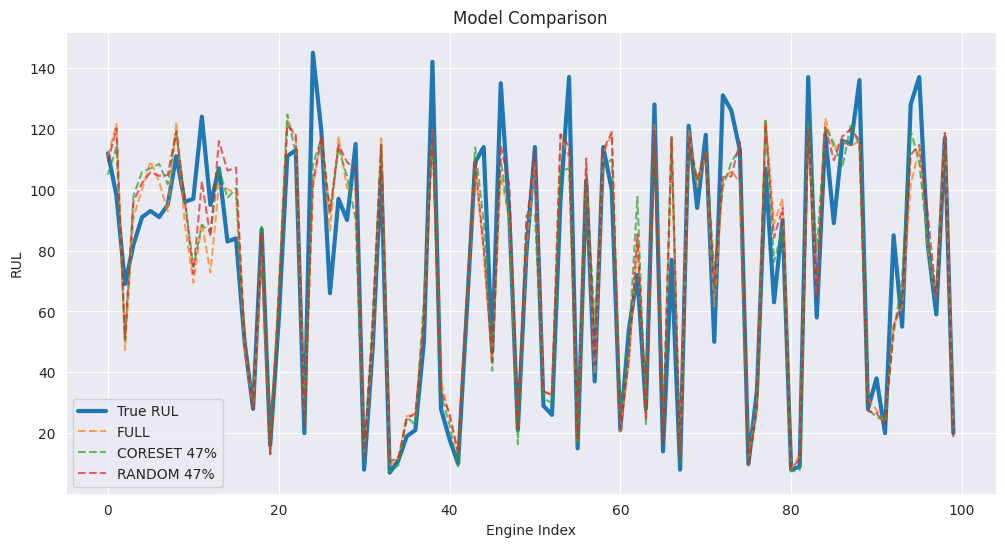

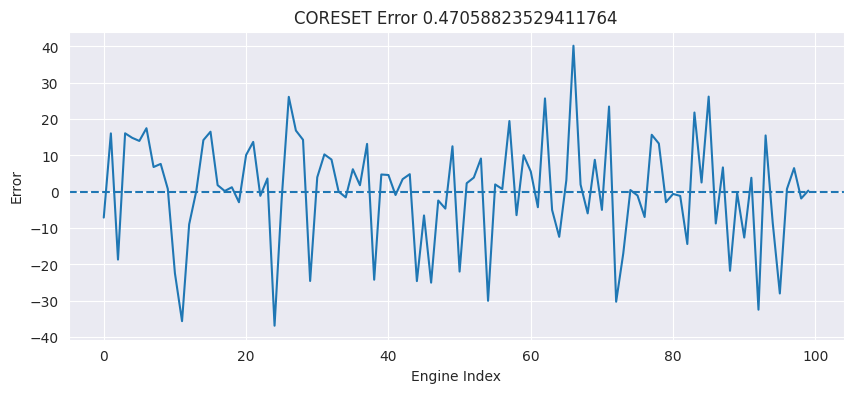


===== Compression Ratio: 0.29 =====

--- Building coreset (29%) ---

=== BIN ALLOCATION ===
Bin 0: allocated=867
Bin 1: allocated=518
Bin 2: allocated=801
Bin 3: allocated=794
Bin 4: allocated=1208

=== CHUNK DEBUG ===
Bin 4: chunks=767, samples=7670, allocated=1208
Bin 3: chunks=528, samples=5280, allocated=794
Bin 2: chunks=480, samples=4800, allocated=801
Bin 1: chunks=480, samples=4800, allocated=518
Bin 0: chunks=480, samples=4800, allocated=867

=== ENGINE COVERAGE DEBUG ===
Total engines: 80
Coreset engines: 80
Engine coverage stats:
min: 0
mean: 41.46534653465346
max: 110

--- Coreset Stats ---
Coreset size: 4188
RUL mean: 76.48567335243553
RUL std: 40.59891919532285
RUL min: 0
RUL max: 125
Target size: 4188, Actual: 4188

=== GLOBAL RETENTION ===
Low-RUL retention (<20): 0.08739255014326648
Original low-RUL fraction: 0.11235166069798469
High-RUL retention (>100): 0.3319006685768863
Original high-RUL fraction: 0.43276455305104977

=== BIN RETENTION DIAGNOSTICS ===
Bin 0: range

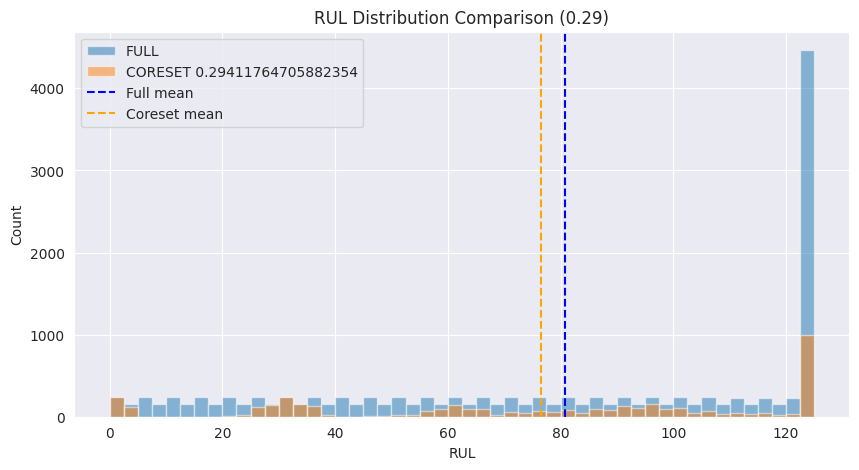


=== QUANTILE DIAGNOSTICS ===
Quantile | Full | Coreset
  0%     |   0.00 |   0.00
 10%     |  17.00 |  26.00
 25%     |  44.00 |  35.00
 50%     |  89.00 |  84.00
 75%     | 125.00 | 118.00
 90%     | 125.00 | 125.00
100%     | 125.00 | 125.00

=== ENGINE COVERAGE ===
Original engines: 80
Coreset engines: 80
Bin 0: 652 samples
Bin 1: 737 samples
Bin 2: 878 samples
Bin 3: 930 samples
Bin 4: 991 samples

FULL:
0.16852749104697703
0.16852749104697703
0.16852749104697703
0.19106804297451022
0.3033494838845587

CORESET:
0.1556829035339064
0.1759789875835721
0.2096466093600764
0.22206303724928367
0.23662846227316142
Epoch 1/100
66/66 ━━━━━━━━━━━━━━━━━━━━ 18s 122ms/step - loss: 7005.7856 - mae: 73.5651 - val_loss: 6897.6191 - val_mae: 72.2949 - learning_rate: 0.0010
Epoch 2/100
66/66 ━━━━━━━━━━━━━━━━━━━━ 9s 132ms/step - loss: 5556.6626 - mae: 64.4535 - val_loss: 5127.2153 - val_mae: 60.9340 - learning_rate: 0.0010
Epoch 3/100
66/66 ━━━━━━━━━━━━━━━━━━━━ 10s 130ms/step - loss: 3714.9604 - mae:

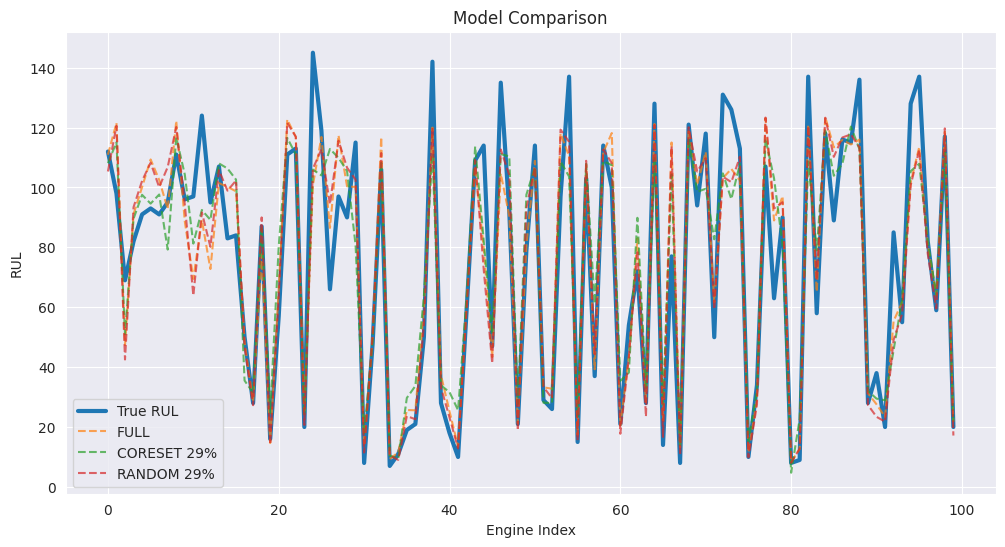

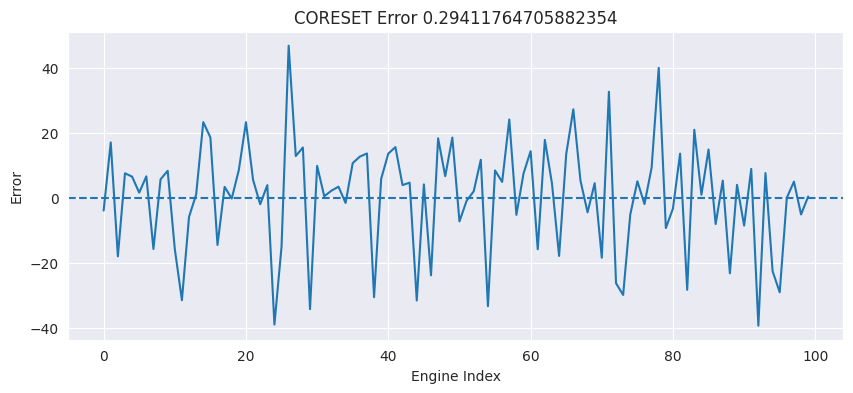


===== Compression Ratio: 0.12 =====

--- Building coreset (12%) ---

=== BIN ALLOCATION ===
Bin 0: allocated=347
Bin 1: allocated=207
Bin 2: allocated=321
Bin 3: allocated=318
Bin 4: allocated=482

=== CHUNK DEBUG ===
Bin 4: chunks=767, samples=7670, allocated=482
Bin 3: chunks=528, samples=5280, allocated=318
Bin 2: chunks=480, samples=4800, allocated=321
Bin 1: chunks=480, samples=4800, allocated=207
Bin 0: chunks=480, samples=4800, allocated=347

=== ENGINE COVERAGE DEBUG ===
Total engines: 80
Coreset engines: 70
Engine coverage stats:
min: 0
mean: 16.584158415841586
max: 51

--- Coreset Stats ---
Coreset size: 1675
RUL mean: 84.20597014925373
RUL std: 36.888730959738965
RUL min: 0
RUL max: 125
Target size: 1675, Actual: 1675

=== GLOBAL RETENTION ===
Low-RUL retention (<20): 0.01791044776119403
Original low-RUL fraction: 0.11235166069798469
High-RUL retention (>100): 0.3856716417910448
Original high-RUL fraction: 0.43276455305104977

=== BIN RETENTION DIAGNOSTICS ===
Bin 0: range=

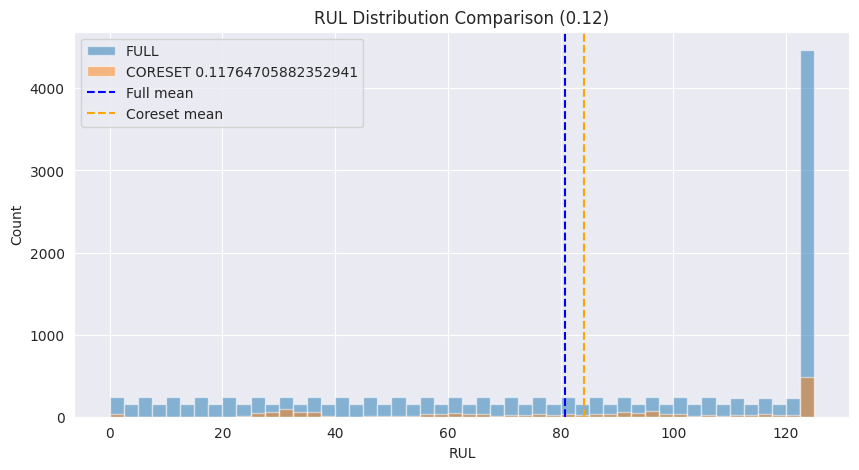


=== QUANTILE DIAGNOSTICS ===
Quantile | Full | Coreset
  0%     |   0.00 |   0.00
 10%     |  17.00 |  30.00
 25%     |  44.00 |  57.00
 50%     |  89.00 |  91.00
 75%     | 125.00 | 125.00
 90%     | 125.00 | 125.00
100%     | 125.00 | 125.00

=== ENGINE COVERAGE ===
Original engines: 80
Coreset engines: 70
Bin 0: 150 samples
Bin 1: 307 samples
Bin 2: 346 samples
Bin 3: 392 samples
Bin 4: 480 samples

FULL:
0.16852749104697703
0.16852749104697703
0.16852749104697703
0.19106804297451022
0.3033494838845587

CORESET:
0.08955223880597014
0.18328358208955223
0.20656716417910448
0.23402985074626867
0.2865671641791045
Epoch 1/100
27/27 ━━━━━━━━━━━━━━━━━━━━ 13s 168ms/step - loss: 8291.9854 - mae: 83.3433 - val_loss: 7731.8184 - val_mae: 77.6145 - learning_rate: 0.0010
Epoch 2/100
27/27 ━━━━━━━━━━━━━━━━━━━━ 4s 146ms/step - loss: 7764.9492 - mae: 80.2580 - val_loss: 7166.5127 - val_mae: 74.0873 - learning_rate: 0.0010
Epoch 3/100
27/27 ━━━━━━━━━━━━━━━━━━━━ 5s 181ms/step - loss: 7123.5234 - mae

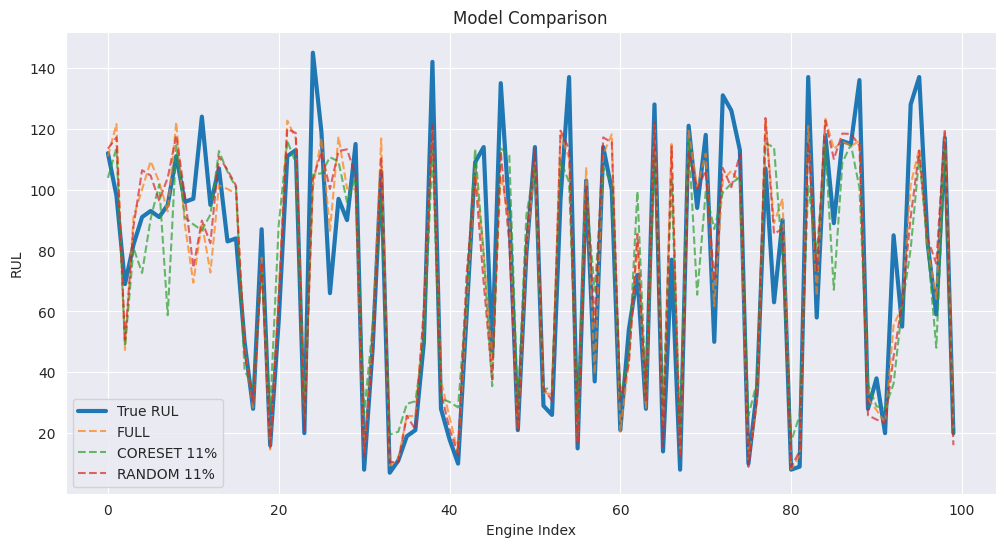

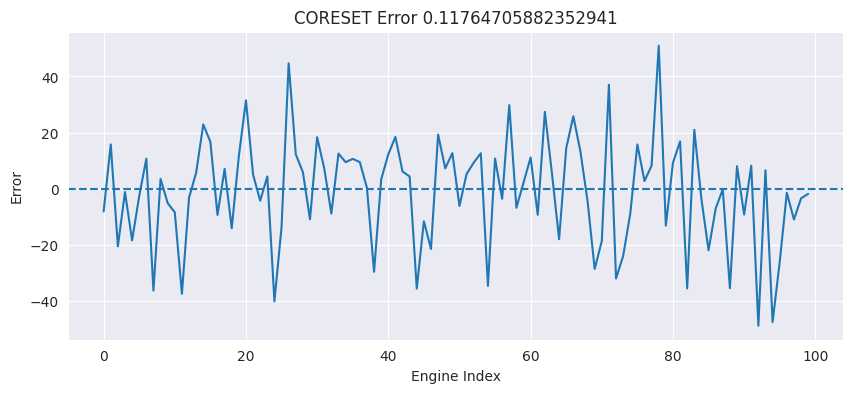


===== Compression Ratio: 0.06 =====

--- Building coreset (6%) ---

=== BIN ALLOCATION ===
Bin 0: allocated=173
Bin 1: allocated=103
Bin 2: allocated=160
Bin 3: allocated=159
Bin 4: allocated=242

=== CHUNK DEBUG ===
Bin 4: chunks=767, samples=7670, allocated=242
Bin 3: chunks=528, samples=5280, allocated=159
Bin 2: chunks=480, samples=4800, allocated=160
Bin 1: chunks=480, samples=4800, allocated=103
Bin 0: chunks=480, samples=4800, allocated=173

=== ENGINE COVERAGE DEBUG ===
Total engines: 80
Coreset engines: 50
Engine coverage stats:
min: 0
mean: 8.287128712871286
max: 51

--- Coreset Stats ---
Coreset size: 837
RUL mean: 83.15412186379929
RUL std: 37.544288753633516
RUL min: 0
RUL max: 125
Target size: 837, Actual: 837

=== GLOBAL RETENTION ===
Low-RUL retention (<20): 0.026284348864994027
Original low-RUL fraction: 0.11235166069798469
High-RUL retention (>100): 0.3751493428912784
Original high-RUL fraction: 0.43276455305104977

=== BIN RETENTION DIAGNOSTICS ===
Bin 0: range=[0, 

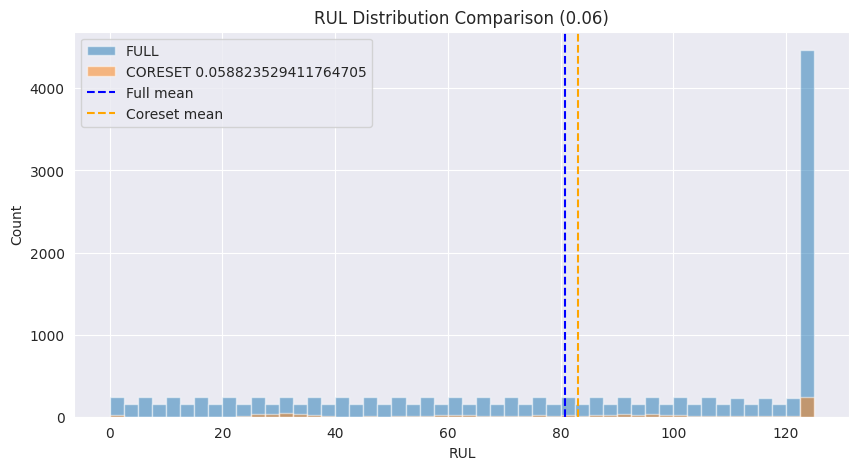


=== QUANTILE DIAGNOSTICS ===
Quantile | Full | Coreset
  0%     |   0.00 |   0.00
 10%     |  17.00 |  30.00
 25%     |  44.00 |  56.00
 50%     |  89.00 |  90.00
 75%     | 125.00 | 125.00
 90%     | 125.00 | 125.00
100%     | 125.00 | 125.00

=== ENGINE COVERAGE ===
Original engines: 80
Coreset engines: 50
Bin 0: 83 samples
Bin 1: 154 samples
Bin 2: 174 samples
Bin 3: 186 samples
Bin 4: 240 samples

FULL:
0.16852749104697703
0.16852749104697703
0.16852749104697703
0.19106804297451022
0.3033494838845587

CORESET:
0.0991636798088411
0.18399044205495818
0.2078853046594982
0.2222222222222222
0.2867383512544803
Epoch 1/100
14/14 ━━━━━━━━━━━━━━━━━━━━ 14s 248ms/step - loss: 8258.9443 - mae: 82.8172 - val_loss: 7957.5928 - val_mae: 78.9730 - learning_rate: 0.0010
Epoch 2/100
14/14 ━━━━━━━━━━━━━━━━━━━━ 3s 190ms/step - loss: 8049.9995 - mae: 81.6946 - val_loss: 7716.8613 - val_mae: 77.5448 - learning_rate: 0.0010
Epoch 3/100
14/14 ━━━━━━━━━━━━━━━━━━━━ 5s 338ms/step - loss: 7761.8550 - mae: 80

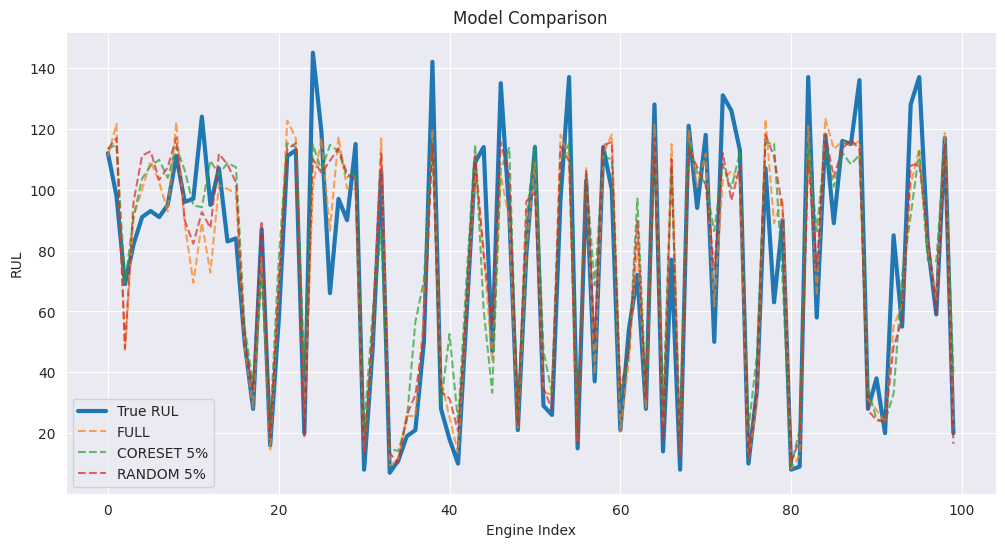

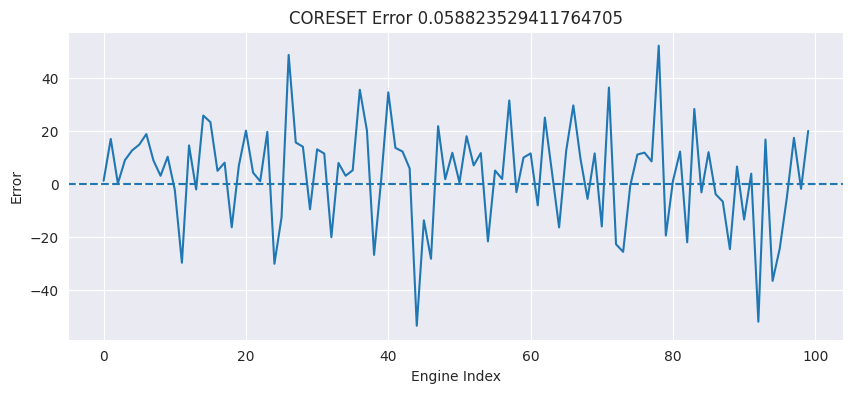

In [ ]:
results, all_coresets = run_experiments_with_baselines(
    X=processed_train_data["X"],
    y=processed_train_data["y_clipped"], #run y_clipped for optimal performance. y_raw used for fair comparison with other compression methodss
    engine_ids=processed_train_data["engine_id"],

    X_val=processed_val_data["X"],
    y_val=processed_val_data["y_clipped"], #same as above

    X_test=processed_test,
    num_test_windows_list=num_test_windows_list,
    true_rul=true_rul,

    similarity_stats=similarity_stats,
    bins=CUSTOM_RUL_BINS,
    importance_dict=importance_dict,
    #14/17, 11/17, 8/17, 5/17, 2/17, 1/17
    #[0.82, 0.65, 0.47, 0.29, 0.12, 0.06]
    compression_ratios=[14/17, 11/17, 8/17, 5/17, 2/17, 1/17]
)

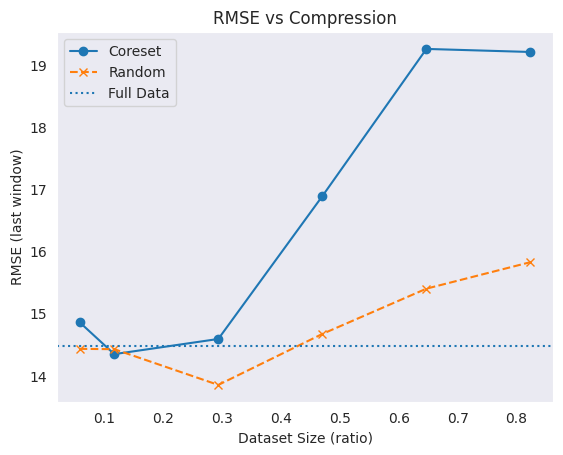

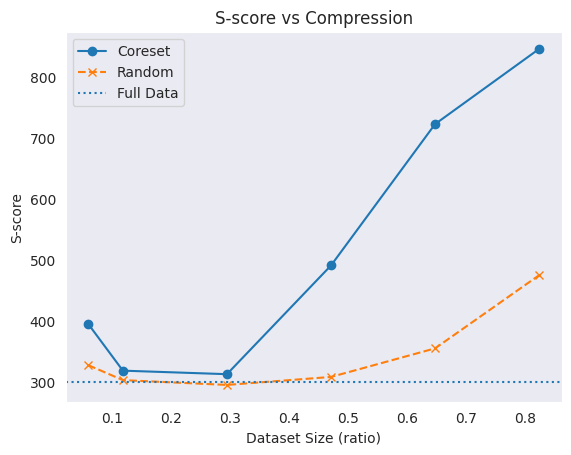

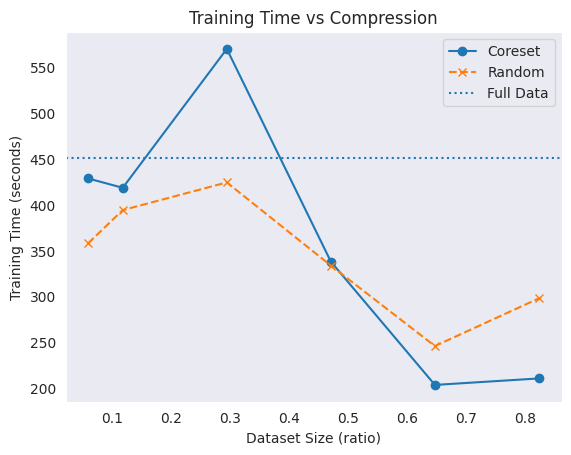

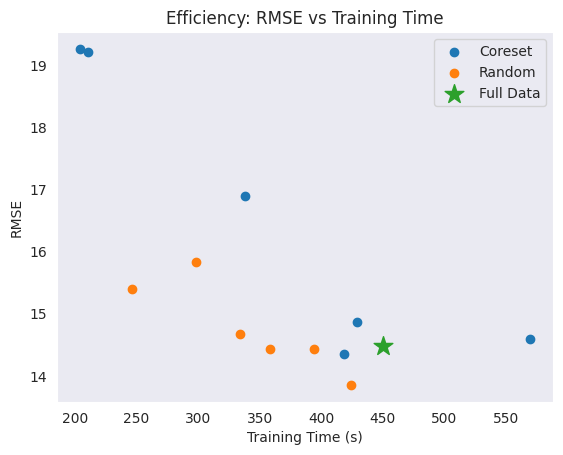

In [ ]:
plot_performance_vs_compression(results)
plot_time_vs_compression(results)
plot_efficiency(results)

Export datasets for comparison with other methods

In [ ]:
import pickle

with open("all_coresets.pkl", "wb") as f:
    pickle.dump(all_coresets, f)

In [ ]:
files.download("all_coresets.pkl")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

#Debugging

Old code used for debugging

In [ ]:
print(type(processed_test))  # should be np.ndarray

<class 'numpy.ndarray'>


In [ ]:
for s in allocation:
    print(s["bin"], s["allocated"])

NameError: name 'allocation' is not defined

In [ ]:
print(np.mean(gradient_features), np.std(gradient_features))

In [ ]:
print("Gradient feature stats:")
print("Mean:", np.mean(gradient_features))
print("Std:", np.std(gradient_features))
print("Min:", np.min(gradient_features))
print("Max:", np.max(gradient_features))

In [ ]:
print("Feature norm stats:")
print(np.mean(np.linalg.norm(gradient_features, axis=1)))
print(np.std(np.linalg.norm(gradient_features, axis=1)))

In [ ]:
print(similarity_stats)

In [ ]:
print(np.unique(processed_train_targets)[:20])

In [ ]:
print(history.history["loss"][:5])

In [ ]:
train_preds = model.predict(processed_train_data).reshape(-1)
print("Train preds:", np.unique(np.round(train_preds, 2))[:20])

test_preds = model.predict(processed_test_data).reshape(-1)
print("Test preds:", np.unique(np.round(test_preds, 2))[:20])

In [ ]:
print(processed_train_targets[:50])

In [ ]:
print(processed_train_targets.mean(), processed_train_targets.std())

In [ ]:
print("y mean/std:", processed_train_targets.mean(), processed_train_targets.std())

#Old Pipeline

In [ ]:
# model = create_model()

# history = model.fit(
#     processed_train_data,
#     processed_train_targets,
#     epochs=50,
#     validation_data=(processed_val_data, processed_val_targets),
#     callbacks=[early_stopping, reduce_lr],
#     batch_size=128,
#     verbose=2,
#     shuffle=False
# )

In [ ]:
# rul_pred = model.predict(processed_test_data).reshape(-1)

# preds_for_each_engine = np.split(
#     rul_pred,
#     np.cumsum(num_test_windows_list)[:-1]
# )

# mean_pred_for_each_engine = [
#     np.mean(engine_preds)
#     for engine_preds in preds_for_each_engine
# ]

# RMSE = np.sqrt(mean_squared_error(true_rul, mean_pred_for_each_engine))

# print("RMSE:", RMSE)

In [ ]:
# model_path = f"FD001_LSTM_piecewise_RMSE_{RMSE:.4f}.keras"
# model.save(model_path)

# print(f"Model saved to: {model_path}")

# all_preds = np.concatenate(preds_for_each_engine)

# mean_pred_for_each_engine = [
#     np.mean(engine_preds)
#     for engine_preds in preds_for_each_engine
# ]

# rmse_mean = np.sqrt(
#     mean_squared_error(true_rul, mean_pred_for_each_engine)
# )

# print("RMSE (mean over windows):", rmse_mean)


# preds_for_last_example = np.array([
#     engine_preds[-1]
#     for engine_preds in preds_for_each_engine
# ])

# rmse_last = np.sqrt(
#     mean_squared_error(true_rul, preds_for_last_example)
# )

# print("RMSE (last window only):", rmse_last)

In [ ]:
# def compute_s_score(rul_true, rul_pred):
#     error = rul_pred - rul_true

#     penalty = np.where(
#         error < 0,
#         np.exp(-error / 13) - 1,
#         np.exp(error / 10) - 1
#     )

#     return np.sum(penalty)

# s_score = compute_s_score(true_rul, preds_for_last_example)
# print("S-score: ", s_score)

In [ ]:
# plt.plot(true_rul, label = "True RUL", color = "orange")
# plt.plot(preds_for_last_example, label = "Pred RUL", color = "blue")
# plt.legend()
# plt.show()

In [ ]:
# plt.plot(true_rul, label="True RUL", color="orange", linewidth=2)
# plt.plot(preds_for_last_example, label="Pred RUL", color="blue", alpha=0.5, linestyle="--")
# plt.legend()
# plt.show()